In [1]:

from __future__ import annotations

import re
import time
import hashlib
import warnings
import textwrap
from pathlib import Path
from datetime import date, datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats as sp_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Configurable params ───────────────────────────────────────────────────────
CACHE_DIR      = Path("fomc_cache")
PARQUET_OUT    = Path("fomc_features.parquet")
START_YEAR     = 2010
END_YEAR       = datetime.today().year
RV_WINDOWS     = [1, 5, 10]        # forward RV horizons in trading days
TFIDF_WINDOW   = 4                 # trailing meetings for novelty centroid
BREVITY_WINDOW = 4                 # trailing meetings for word-count z-score
RATE_LIMIT_S   = 1.5               # seconds between Fed website requests
REGIME_CSV     = Path("fomc_regime.csv")   # optional — see Layer 3

CACHE_DIR.mkdir(exist_ok=True)
(CACHE_DIR / "html").mkdir(exist_ok=True)
(CACHE_DIR / "market").mkdir(exist_ok=True)

print(f"Cache : {CACHE_DIR.resolve()}")
print(f"Out   : {PARQUET_OUT.resolve()}")

Cache : /Users/zinuoshi/fomc_cache
Out   : /Users/zinuoshi/fomc_features.parquet


---
# LAYER 1 — ACQUISITION: FOMC TEXT + MEETING CALENDAR

In [2]:

# Statement release dates (last day of each scheduled/emergency meeting).
# Source: https://www.federalreserve.gov/monetarypolicy/fomchistorical{YEAR}.htm
#         https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm
# Emergency meetings (Mar 2020) are included; presser_available is flagged separately.

_HARDCODED_DATES: list[str] = [
    # 2010
    "2010-01-27","2010-03-16","2010-04-28","2010-06-23",
    "2010-08-10","2010-09-21","2010-11-03","2010-12-14",
    # 2011
    "2011-01-26","2011-03-15","2011-04-27","2011-06-22",
    "2011-08-09","2011-09-21","2011-11-02","2011-12-13",
    # 2012
    "2012-01-25","2012-03-13","2012-04-25","2012-06-20",
    "2012-08-01","2012-09-13","2012-10-24","2012-12-12",
    # 2013
    "2013-01-30","2013-03-20","2013-05-01","2013-06-19",
    "2013-07-31","2013-09-18","2013-10-30","2013-12-18",
    # 2014
    "2014-01-29","2014-03-19","2014-04-30","2014-06-18",
    "2014-07-30","2014-09-17","2014-10-29","2014-12-17",
    # 2015
    "2015-01-28","2015-03-18","2015-04-29","2015-06-17",
    "2015-07-29","2015-09-17","2015-10-28","2015-12-16",
    # 2016
    "2016-01-27","2016-03-16","2016-04-27","2016-06-15",
    "2016-07-27","2016-09-21","2016-11-02","2016-12-14",
    # 2017
    "2017-02-01","2017-03-15","2017-05-03","2017-06-14",
    "2017-07-26","2017-09-20","2017-11-01","2017-12-13",
    # 2018
    "2018-01-31","2018-03-21","2018-05-02","2018-06-13",
    "2018-08-01","2018-09-26","2018-11-08","2018-12-19",
    # 2019
    "2019-01-30","2019-03-20","2019-05-01","2019-06-19",
    "2019-07-31","2019-09-18","2019-10-30","2019-12-11",
    # 2020 (two emergency intermeeting actions: Mar 3 and Mar 15)
    "2020-01-29","2020-03-03","2020-03-15","2020-04-29",
    "2020-06-10","2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    # 2021
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16",
    "2021-07-28","2021-09-22","2021-11-03","2021-12-15",
    # 2022
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15",
    "2022-07-27","2022-09-21","2022-11-02","2022-12-14",
    # 2023
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14",
    "2023-07-26","2023-09-20","2023-11-01","2023-12-13",
    # 2024
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12",
    "2024-07-31","2024-09-18","2024-11-07","2024-12-18",
    # 2025 — verify at https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm
    "2025-01-29","2025-03-19","2025-05-07","2025-06-18",
    "2025-07-30","2025-09-17","2025-10-29","2025-12-10",
    # 2026 (stub — scrape or update manually)
    "2026-01-28","2026-03-18","2026-04-29","2026-06-17",
]

# Chair assignment — update the Warsh start date to the confirmed confirmation date.
_CHAIR_PERIODS: list[tuple[date, date, str]] = [
    (date(2010, 1,  1), date(2014, 1, 31), "Bernanke"),
    (date(2014, 2,  1), date(2018, 2,  2), "Yellen"),
    (date(2018, 2,  3), date(2026, 6, 16), "Powell"),
    (date(2026, 6, 17), date(2030, 1,  1), "Warsh"),
]

# Press conferences: quarterly Apr 2011–Dec 2018; every meeting Jan 2019+.
# Emergency intermeeting actions never have a press conference.
_QUARTERLY_PRESSER_MONTHS = {1, 4, 6, 9, 12}   # approximate quarterly schedule


def _assign_chair(d: date) -> str:
    for start, end, name in _CHAIR_PERIODS:
        if start <= d <= end:
            return name
    return "Unknown"


def _has_presser(d: date, is_emergency: bool = False) -> bool:
    if is_emergency:
        return False
    if d >= date(2019, 1, 1):
        return True
    # Quarterly Apr 2011 – Dec 2018: press conf in Jan/Apr/Jun/Sep/Dec approximately
    if date(2011, 4, 1) <= d <= date(2018, 12, 31):
        return d.month in _QUARTERLY_PRESSER_MONTHS
    return False


def build_fomc_calendar() -> pd.DataFrame:
    """
    Build a DataFrame of FOMC statement release dates with chair and presser flag.
    Returns one row per meeting with columns:
        meeting_date (date), chair (str), presser_available (bool)
    """
    rows = []
    for ds in _HARDCODED_DATES:
        d = datetime.strptime(ds, "%Y-%m-%d").date()
        if d.year < START_YEAR or d.year > END_YEAR:
            continue
        rows.append({
            "meeting_date":      d,
            "chair":             _assign_chair(d),
            "presser_available": _has_presser(d),
        })
    cal = pd.DataFrame(rows).sort_values("meeting_date").reset_index(drop=True)
    print(f"Calendar: {len(cal)} meetings  {cal.meeting_date.min()} → {cal.meeting_date.max()}")
    print(cal.groupby("chair").size().to_string())
    return cal


calendar_df = build_fomc_calendar()

Calendar: 133 meetings  2010-01-27 → 2026-06-17
chair
Bernanke    33
Powell      67
Warsh        1
Yellen      32


In [3]:

_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
}


def fetch_url(url: str, *, delay: float = RATE_LIMIT_S,
              timeout: int = 20) -> Optional[str]:
    """
    Fetch URL with disk cache (keyed by URL hash).  Returns HTML string or
    None if the request fails.  Cached responses skip the delay.
    """
    key  = hashlib.md5(url.encode()).hexdigest()[:16]
    path = CACHE_DIR / "html" / f"{key}.html"

    if path.exists():
        return path.read_text(encoding="utf-8", errors="replace")

    time.sleep(delay)
    try:
        r = requests.get(url, headers=_HEADERS, timeout=timeout)
        r.raise_for_status()
        html = r.text
        path.write_text(html, encoding="utf-8")
        return html
    except requests.RequestException as exc:
        print(f"  FETCH FAILED  {url}\n  {exc}")
        return None

In [4]:

FED_BASE         = "https://www.federalreserve.gov"
STATEMENT_URL_T  = FED_BASE + "/newsevents/pressreleases/monetary{date}a.htm"
PRESSCONF_URL_T  = FED_BASE + "/monetarypolicy/fomcpresconf{date}.htm"


def _extract_statement_text(html: str) -> tuple[str, str]:
    """
    Parse Fed statement HTML.  Returns (raw_text, cleaned_text).
    Strips 'For release at...' header and 'Voting for the FOMC...' footer.

    The modern Fed page has TWO col-xs-12 col-sm-8 divs:
      1. class='heading col-xs-12 ...' — breadcrumb/title (skip)
      2. class='col-xs-12 col-sm-8 ...' — actual statement body (use this)
    We select the non-heading one explicitly.
    """
    soup = BeautifulSoup(html, "html.parser")

    # Modern layout: find content div that is NOT the heading nav div
    content = soup.find(
        "div",
        class_=lambda c: c and "col-xs-12" in c and "col-sm-8" in c and "heading" not in c,
    )
    # Fallbacks for older layouts (pre-2017) and edge cases
    if content is None:
        content = (
            soup.find("div", id="article")
            or soup.find("div", id="leftText")
            or soup.find("article")
            or soup.body
        )

    paragraphs = [p.get_text(" ", strip=True)
                  for p in (content or soup).find_all("p")]
    raw_text = "\n\n".join(p for p in paragraphs if p)

    # ── Clean: skip release-time header; stop at voting-record footer ────
    body_paras: list[str] = []
    in_body = False
    for para in paragraphs:
        lo = para.lower()
        # Stop at voting record or chair signature block
        if re.search(r"voting (for|against) the fomc", lo):
            break
        if re.search(r"^chair(man|woman|person)?[\s,]", lo):
            break
        # Skip the "For release at 2:00 p.m." opener (re.search, not re.match)
        if not in_body and re.search(r"for release at", lo):
            in_body = True
            continue
        # Start body at first substantive paragraph (≥15 words)
        if not in_body and len(para.split()) >= 15:
            in_body = True
        if in_body and len(para.split()) > 3:
            body_paras.append(para)

    cleaned = re.sub(r"\s+", " ", " ".join(body_paras)).strip()

    # Fallback: if cleaning stripped too much, use all paragraphs
    if len(cleaned.split()) < 20 and raw_text:
        cleaned = re.sub(r"\s+", " ", raw_text).strip()

    return raw_text.strip(), cleaned


def scrape_statement(d: date) -> Optional[tuple[str, str]]:
    """Fetch and clean FOMC statement for a given date. Returns (raw, cleaned)."""
    url  = STATEMENT_URL_T.format(date=d.strftime("%Y%m%d"))
    html = fetch_url(url)
    if html is None:
        return None
    return _extract_statement_text(html)


def scrape_pressconf(d: date) -> Optional[tuple[str, str]]:
    """
    Fetch and clean press conference transcript.
    Returns (raw, cleaned) or None if unavailable.
    Transcript pages link to a PDF or HTML; we parse the HTML version.
    """
    url  = PRESSCONF_URL_T.format(date=d.strftime("%Y%m%d"))
    html = fetch_url(url)
    if html is None:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = soup.find("div", class_=re.compile(r"col-xs-12.*col-sm-8")) or soup.body
    raw     = " ".join(p.get_text(" ", strip=True) for p in (content or soup).find_all("p"))
    cleaned = re.sub(r"\s+", " ", raw).strip()
    return (raw, cleaned) if len(cleaned.split()) > 50 else None

In [5]:

def build_docs_raw(calendar: pd.DataFrame) -> pd.DataFrame:
    """
    Scrape statements (and pressers where available) for every meeting.
    Emits a URL manifest if fetching is blocked so the user can
    bulk-download manually and re-run.

    Returns docs_raw with columns:
        meeting_date, doc_type, chair, text, n_words, presser_available
    """
    rows: list[dict] = []
    failed_urls: list[str] = []

    for _, row in calendar.iterrows():
        d     = row["meeting_date"]
        chair = row["chair"]
        pa    = row["presser_available"]

        # ── Statement ────────────────────────────────────────────────────
        result = scrape_statement(d)
        if result is None:
            url = STATEMENT_URL_T.format(date=d.strftime("%Y%m%d"))
            failed_urls.append(url)
            print(f"  MISS statement {d}")
        else:
            raw, cleaned = result
            rows.append({
                "meeting_date":      d,
                "doc_type":          "statement",
                "chair":             chair,
                "text_raw":          raw,
                "text":              cleaned,
                "n_words":           len(cleaned.split()),
                "presser_available": pa,
            })

        # ── Press conference (where expected) ───────────────────────────
        if pa:
            result_p = scrape_pressconf(d)
            if result_p is not None:
                raw_p, cleaned_p = result_p
                rows.append({
                    "meeting_date":      d,
                    "doc_type":          "presser",
                    "chair":             chair,
                    "text_raw":          raw_p,
                    "text":              cleaned_p,
                    "n_words":           len(cleaned_p.split()),
                    "presser_available": pa,
                })

    if failed_urls:
        manifest = CACHE_DIR / "failed_urls.txt"
        manifest.write_text("\n".join(failed_urls))
        print(f"\n  {len(failed_urls)} URLs failed — manifest saved to {manifest}")
        print("  Download the pages manually, save as <YYYYMMDD>.html in fomc_cache/html/,")
        print("  then re-run: fetch_url() will pick up the cached files automatically.")

    docs = pd.DataFrame(rows)
    docs["meeting_date"] = pd.to_datetime(docs["meeting_date"])
    print(f"\ndocs_raw: {docs.shape}")
    print(docs.groupby("doc_type")["meeting_date"].count().to_string())
    return docs


docs_raw = build_docs_raw(calendar_df)

  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20110921.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20110921.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20111213.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20111213.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20130130.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20130130.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140129.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140129.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140430.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140430.htm


...

  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20150429.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20150429.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160127.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160127.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160427.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160427.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20180131.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20180131.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20260128.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20260128.htm

docs_raw: (216, 7)
doc_type
presser       83
statement    133


In [6]:
# Pages that returned a JS-disabled stub or a nav-only redirect produce very
# short "cleaned" text (< 50 words).  Remove those rows and delete their cache
# files so the next run re-fetches from the corrected extractor.

MIN_STATEMENT_WORDS = 50

def purge_bad_scrapes(docs: pd.DataFrame, min_words: int = MIN_STATEMENT_WORDS,
                      cache_dir: Path = CACHE_DIR) -> pd.DataFrame:
    """
    Remove rows where cleaned text is too short, and wipe their HTML cache so
    they are re-fetched on next run with the fixed extractor.
    """
    import hashlib
    bad = docs[docs["n_words"] < min_words]
    if bad.empty:
        print(f"  No bad scrapes detected (all ≥ {min_words} words).")
        return docs

    print(f"  Purging {len(bad)} short-text rows (< {min_words} words):")
    for _, row in bad.iterrows():
        d  = row["meeting_date"]
        dt = d.date() if hasattr(d, "date") else d
        dt_str = dt.strftime("%Y%m%d")
        if row["doc_type"] == "statement":
            url = STATEMENT_URL_T.format(date=dt_str)
        else:
            url = PRESSCONF_URL_T.format(date=dt_str)
        key  = hashlib.md5(url.encode()).hexdigest()[:16]
        path = cache_dir / "html" / f"{key}.html"
        if path.exists():
            path.unlink()
            print(f"    cleared cache: {dt_str} {row['doc_type']}")
        else:
            print(f"    no cache file: {dt_str} {row['doc_type']} (will re-fetch)")

    clean = docs[docs["n_words"] >= min_words].copy().reset_index(drop=True)
    print(f"  docs_raw after purge: {clean.shape}")
    return clean


docs_raw = purge_bad_scrapes(docs_raw)

  No bad scrapes detected (all ≥ 50 words).


---
# LAYER 2 — FOUR FEATURE FAMILIES
Computed on the **statement** corpus. Presser features suffixed `_presser`
where computed separately. POLARITY is a control/direction overlay — it is
**not** in the vol-prediction feature set.

In [7]:

stmt = (
    docs_raw[docs_raw["doc_type"] == "statement"]
    .sort_values("meeting_date")
    .reset_index(drop=True)
    .copy()
)
print(f"Statements: {len(stmt)}")

Statements: 133


In [8]:

def compute_family_a(stmt_df: pd.DataFrame, window: int = BREVITY_WINDOW) -> pd.DataFrame:
    """
    Family A: Word-count features per statement.

    Columns added:
        word_count            — raw word count of cleaned statement
        word_count_change     — vs trailing mean of prior `window` meetings
        word_count_zscore     — (word_count - trailing mean) / trailing std
        word_count_pct_rank   — expanding percentile rank (0-1)

    The most direct Warsh signal: very short or abruptly shorter statements
    → high brevity deviation → elevated vol risk ex-ante.
    """
    df = stmt_df.copy()
    wc = df["n_words"].astype(float)

    trailing_mean = wc.shift(1).rolling(window, min_periods=2).mean()
    trailing_std  = wc.shift(1).rolling(window, min_periods=2).std(ddof=1)

    df["word_count"]        = wc
    df["word_count_change"] = wc - trailing_mean
    df["word_count_zscore"] = (wc - trailing_mean) / trailing_std.replace(0, np.nan)
    df["word_count_pct_rank"] = wc.expanding().rank(pct=True)

    print("Family A — brevity features:")
    print(df[["meeting_date", "word_count", "word_count_change",
              "word_count_zscore"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_a(stmt)

Family A — brevity features:
meeting_date  word_count  word_count_change  word_count_zscore
  2025-10-29       382.0              46.75           2.734666
  2025-12-10       402.0              55.75           1.904476
  2026-01-28       308.0             -61.00          -2.172116
  2026-03-18       322.0             -38.75          -0.946272
  2026-04-29       357.0               3.50           0.076823
  2026-06-17       147.0            -200.25          -4.777459


In [9]:

def compute_family_b(stmt_df: pd.DataFrame, window: int = TFIDF_WINDOW) -> pd.DataFrame:
    """
    Family B: TF-IDF cosine distance features (pure scikit-learn, no downloads).

    Columns added:
        novelty_prev    — cosine distance to immediately prior statement (0=identical)
        novelty_window  — cosine distance to centroid of prior `window` statements
        novelty_zscore  — novelty_prev z-scored vs expanding window

    Spikes when a new Chair breaks template language.
    All computations are strictly backward-looking (no lookahead).
    """
    texts = stmt_df["text"].fillna("").tolist()
    n     = len(texts)

    # Fit TF-IDF on the full corpus (in-sample; for a strict walk-forward,
    # refit incrementally — acceptable here since vocab doesn't cause leakage)
    tfidf   = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                               min_df=2, sublinear_tf=True)
    mat     = tfidf.fit_transform(texts)    # (n_meetings, vocab)

    novelty_prev   = np.full(n, np.nan)
    novelty_window = np.full(n, np.nan)

    for i in range(1, n):
        vec_i = mat[i]
        # Distance to prior
        sim_prev          = cosine_similarity(vec_i, mat[i - 1])[0, 0]
        novelty_prev[i]   = 1.0 - float(sim_prev)
        # Distance to trailing-window centroid
        # np.asarray() converts sparse matrix mean (np.matrix) to ndarray
        start             = max(0, i - window)
        centroid          = np.asarray(mat[start:i].mean(axis=0))
        sim_win           = cosine_similarity(vec_i, centroid)[0, 0]
        novelty_window[i] = 1.0 - float(sim_win)

    df = stmt_df.copy()
    df["novelty_prev"]   = novelty_prev
    df["novelty_window"] = novelty_window

    # Z-score novelty_prev against expanding history (prevents lookahead)
    expanding_mean = pd.Series(novelty_prev).expanding().mean()
    expanding_std  = pd.Series(novelty_prev).expanding().std(ddof=1)
    df["novelty_zscore"] = (
        (pd.Series(novelty_prev) - expanding_mean) / expanding_std.replace(0, np.nan)
    ).values

    print("Family B — novelty features:")
    print(df[["meeting_date", "novelty_prev",
              "novelty_window", "novelty_zscore"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_b(stmt)

Family B — novelty features:
meeting_date  novelty_prev  novelty_window  novelty_zscore
  2025-10-29      0.137135        0.201324       -0.198736
  2025-12-10      0.079254        0.138116       -0.724961
  2026-01-28      0.239847        0.212738        0.745347
  2026-03-18      0.067833        0.144082       -0.831647
  2026-04-29      0.128681        0.141765       -0.270104
  2026-06-17      0.646787        0.661623        4.187381


In [10]:
# Wordlists embedded inline (no internet required).

# Forward guidance scaffolding phrases — ABSENCE is the vol signal.
_GUIDANCE_PHRASES = [
    r"likely to be appropriate",
    r"anticipate[sd]?\b",
    r"for (some time|an extended period)",
    r"at least .{0,20} meeting[s]?",
    r"calendar.based",
    r"outcome.based",
    r"until .{0,30} (achiev|reach|return)",
    r"well-anchored",
    r"balance sheet normali",
    r"gradual(ly)?",
    r"(exceptionally|historically) low",
    r"patient",
    r"data.depend",
    r"(will|would) be (appropriate|warranted)",
    r"symmetric .{0,10} (inflation|target)",
    r"maximum employment",
    r"(accommodative|restrictive) (for|stance)",
]

# Loughran-McDonald uncertainty words (curated subset; full list at
# https://sraf.nd.edu/loughranmcdonald-master-dictionary/)
_LM_UNCERTAINTY = {
    "uncertain", "uncertainty", "unpredictable", "unpredictability",
    "ambiguous", "ambiguity", "approximate", "approximately", "unclear",
    "indefinite", "indefinitely", "vague", "vaguer", "unsettled",
    "doubt", "doubts", "doubtful", "doubtfully", "questionable",
    "question", "possible", "possibly", "variable", "variability",
    "depend", "depends", "dependent", "contingent", "tentative",
    "tentatively", "indeterminate", "unstable", "unstability",
    "fluctuate", "fluctuates", "fluctuating", "volatile", "volatility",
    "challenging", "unusual", "atypical", "unprecedented", "evolving",
    "reassess", "reassessment", "reconsider", "revisit",
}

# Weak modal verbs (another uncertainty proxy)
_WEAK_MODALS = {"might", "could", "may", "would", "should", "can",
                "seems", "appear", "appears", "suggest", "suggests"}

# Hawk-dove lexicon (used ONLY as control — not in vol feature set)
_HAWK_TOKENS = {
    "inflationary", "overheat", "tighten", "tightening", "restrictive",
    "above target", "price stability", "raise rates", "increase rates",
    "normalize", "higher rates", "vigilant", "premature", "front-load",
}
_DOVE_TOKENS = {
    "accommodative", "easing", "support", "stimulate", "slack",
    "below target", "underemployment", "lower rates", "reduce rates",
    "patient", "gradual", "transitory", "muted", "subdued",
}


def _regex_density(text: str, patterns: list[str]) -> float:
    """Hits-per-100-words for a list of regex patterns."""
    hits = sum(len(re.findall(p, text, re.IGNORECASE)) for p in patterns)
    wc   = max(len(text.split()), 1)
    return hits / wc * 100


def _token_density(text: str, wordset: set[str]) -> float:
    """Fraction of tokens matching wordset."""
    tokens = re.findall(r"\b\w+\b", text.lower())
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in wordset) / len(tokens)


def compute_family_c(stmt_df: pd.DataFrame,
                     window: int = BREVITY_WINDOW) -> pd.DataFrame:
    """
    Family C: Ambiguity and guidance-withdrawal features.

    guidance_density   — hits-per-100-words of forward-guidance scaffolding phrases
    guidance_presence  — binary: guidance_density above historical median
    guidance_change    — guidance_density vs trailing mean (drop = withdrawal signal)
    uncertainty_density — LM uncertainty word density
    weak_modal_density  — weak modal verb density
    """
    df = stmt_df.copy()

    df["guidance_density"]   = df["text"].apply(
        lambda t: _regex_density(t, _GUIDANCE_PHRASES))
    df["uncertainty_density"] = df["text"].apply(
        lambda t: _token_density(t, _LM_UNCERTAINTY))
    df["weak_modal_density"]  = df["text"].apply(
        lambda t: _token_density(t, _WEAK_MODALS))

    hist_med = df["guidance_density"].expanding().median()
    df["guidance_presence"] = (df["guidance_density"] > hist_med).astype(int)

    trail_mean = df["guidance_density"].shift(1).rolling(window, min_periods=2).mean()
    df["guidance_change"] = df["guidance_density"] - trail_mean

    print("Family C — ambiguity/guidance features:")
    print(df[["meeting_date", "guidance_density", "guidance_presence",
              "uncertainty_density"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_c(stmt)

Family C — ambiguity/guidance features:
meeting_date  guidance_density  guidance_presence  uncertainty_density
  2025-10-29          0.523560                  0             0.005128
  2025-12-10          0.497512                  0             0.004843
  2026-01-28          0.649351                  0             0.006309
  2026-03-18          0.621118                  0             0.009036
  2026-04-29          0.560224                  0             0.005464
  2026-06-17          0.000000                  0             0.006452


In [11]:

_DISAGREE_PATTERNS = [
    r"\bsome\b .{0,30}\bparticipants?\b",
    r"\bseveral\b .{0,30}\bparticipants?\b",
    r"\ba few\b .{0,30}\bparticipants?\b",
    r"\bmany\b .{0,30}\bparticipants?\b",
    r"\bmost\b .{0,30}\bparticipants?\b",
    r"\bdiverge",
    r"\bdisagree",
    r"\bdiffering\b",
    r"\bcautioned\b",
    r"\bpreferred\b .{0,30}(more|less|larger|smaller)",
]


def compute_family_d(stmt_df: pd.DataFrame) -> pd.DataFrame:
    """
    Family D: Disagreement / heterogeneity.

    On statements (not minutes), true cross-member dispersion is unobservable.
    We use hedged-quantifier density as a proxy for the committee's internal
    heterogeneity that the Chair felt obliged to surface publicly.
    Returns disagree_density (hits/100 words); null where uninformative.

    NOTE: Minutes-based dispersion would be more powerful but requires separate
    scraping. Leave a stub column `disagree_density_minutes` = null with a TODO.
    """
    df = stmt_df.copy()
    df["disagree_density"] = df["text"].apply(
        lambda t: _regex_density(t, _DISAGREE_PATTERNS))
    df["disagree_density_minutes"] = np.nan   # TODO: join minutes scrape

    print("Family D — disagreement proxy:")
    print(df[["meeting_date", "disagree_density"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_d(stmt)

Family D — disagreement proxy:
meeting_date  disagree_density
  2025-10-29               0.0
  2025-12-10               0.0
  2026-01-28               0.0
  2026-03-18               0.0
  2026-04-29               0.0
  2026-06-17               0.0


In [12]:
# NOT a vol predictor. Label clearly as direction overlay.

def compute_polarity_control(stmt_df: pd.DataFrame) -> pd.DataFrame:
    """
    Control: hawk-dove polarity score (positive = hawkish).
    Based on token-density lexicon; NOT included in vol feature families.
    Used as a control variable and direction overlay only.
    """
    df = stmt_df.copy()
    df["hawk_density"] = df["text"].apply(lambda t: _token_density(t, _HAWK_TOKENS))
    df["dove_density"] = df["text"].apply(lambda t: _token_density(t, _DOVE_TOKENS))
    df["polarity_hd"]  = df["hawk_density"] - df["dove_density"]   # >0 = hawkish
    return df


stmt = compute_polarity_control(stmt)

In [13]:

TEXT_FEATURE_COLS = [
    # Family A
    "word_count", "word_count_change", "word_count_zscore", "word_count_pct_rank",
    # Family B
    "novelty_prev", "novelty_window", "novelty_zscore",
    # Family C
    "guidance_density", "guidance_presence", "guidance_change",
    "uncertainty_density", "weak_modal_density",
    # Family D
    "disagree_density",
    # Control (direction, not vol)
    "polarity_hd",
]

features_text = stmt[
    ["meeting_date", "chair", "presser_available"] + TEXT_FEATURE_COLS
].copy()

print(f"\nfeatures_text: {features_text.shape}")
print(features_text.isnull().sum()[features_text.isnull().sum() > 0].to_string())
print(features_text.tail(4).to_string(index=False))


features_text: (133, 17)
word_count_change    2
word_count_zscore    2
novelty_prev         1
novelty_window       1
novelty_zscore       2
guidance_change      2
meeting_date  chair  presser_available  word_count  word_count_change  word_count_zscore  word_count_pct_rank  novelty_prev  novelty_window  novelty_zscore  guidance_density  guidance_presence  guidance_change  uncertainty_density  weak_modal_density  disagree_density  polarity_hd
  2026-01-28 Powell               True       308.0             -61.00          -2.172116             0.107692      0.239847        0.212738        0.745347          0.649351                  0         0.105005             0.006309            0.009464               0.0    -0.003155
  2026-03-18 Powell               True       322.0             -38.75          -0.946272             0.156489      0.067833        0.144082       -0.831647          0.621118                  0         0.061062             0.009036            0.009036               0.0    

---
# LAYER 3 — PUBLIC-DATA REALIZED VOL + REGIME

In [14]:

FRED_SERIES = {
    "DGS2":  "yield_2y",
    "DGS5":  "yield_5y",
    "DGS10": "yield_10y",
    "DGS30": "yield_30y",
}
FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"


def fetch_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    """
    Download a FRED series as a daily pd.Series via the public CSV endpoint.
    Caches to disk. Values are percentages (e.g. 4.25 for 4.25%).
    """
    cache_path = CACHE_DIR / "market" / f"fred_{series_id}.csv"
    if cache_path.exists():
        df_c = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        s    = df_c.iloc[:, 0].replace(".", np.nan).astype(float)
    else:
        url  = FRED_CSV_URL.format(series=series_id)
        time.sleep(0.5)
        try:
            df_c = pd.read_csv(url, index_col=0, parse_dates=True)
            df_c.to_csv(cache_path)
            s    = df_c.iloc[:, 0].replace(".", np.nan).astype(float)
        except Exception as exc:
            print(f"  FRED fetch failed for {series_id}: {exc}")
            return pd.Series(dtype=float, name=series_id)

    mask = (s.index >= pd.Timestamp(start)) & (s.index <= pd.Timestamp(end))
    return s.loc[mask].rename(series_id)


def build_yield_panel(start: str, end: str) -> pd.DataFrame:
    """
    Fetch all FRED yield series; return a daily DataFrame aligned on business days.
    Missing values (weekends, holidays) are forward-filled (FRED convention).
    """
    series_dict = {}
    for fred_id, col_name in FRED_SERIES.items():
        s = fetch_fred_series(fred_id, start, end)
        if not s.empty:
            series_dict[col_name] = s.rename(col_name)

    yields = pd.DataFrame(series_dict)
    yields.index = pd.to_datetime(yields.index)
    yields = yields.sort_index().ffill()
    print(f"Yield panel: {yields.shape}  {yields.index.min().date()} → {yields.index.max().date()}")
    print(yields.tail(3).to_string())
    return yields


market_start = f"{START_YEAR - 1}-01-01"   # one year buffer for lagged RV
market_end   = f"{END_YEAR}-12-31"
yields_df    = build_yield_panel(market_start, market_end)

Yield panel: (4556, 4)  2009-01-01 → 2026-06-18
                  yield_2y  yield_5y  yield_10y  yield_30y
observation_date                                          
2026-06-16            4.05      4.16       4.43       4.93
2026-06-17            4.20      4.27       4.49       4.93
2026-06-18            4.19      4.23       4.46       4.90


In [15]:

def compute_rv(
    yields:      pd.DataFrame,
    fomc_dates:  list,
    tenors:      list[str] | None = None,
    k_list:      list[int]        = RV_WINDOWS,
    direction:   str              = "forward",
) -> pd.DataFrame:
    """
    Realized vol on daily yield *changes* (basis-point moves per day).

    RV = sqrt(252 / n_obs * sum(dr^2))  where dr = daily yield change in pp.
    Annualised in percentage-point / day units — comparable to IV in pp.

    Parameters
    ----------
    yields     : daily yield panel (percentage points, e.g. 4.25 for 4.25%)
    fomc_dates : list of meeting dates
    tenors     : subset of yield columns to use; defaults to all
    k_list     : forward window lengths in trading days
    direction  : "forward" or "backward"

    Returns
    -------
    DataFrame indexed by meeting_date with columns rv_{tenor}_{k}d
    """
    tenors = tenors or list(yields.columns)
    diffs  = yields[tenors].diff().dropna()   # daily yield changes (pp)
    rows: list[dict] = []

    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        row   = {"meeting_date": fd}

        for k in k_list:
            for tenor in tenors:
                series = diffs[tenor].dropna()
                if direction == "forward":
                    window = series[series.index > fd_ts].iloc[:k]
                else:
                    window = series[series.index < fd_ts].iloc[-k:]

                if len(window) < max(2, int(k * 0.6)):
                    row[f"rv_{tenor}_{k}d"] = np.nan
                else:
                    rv_val = np.sqrt(252 / len(window) * (window ** 2).sum())
                    row[f"rv_{tenor}_{k}d"] = rv_val

        rows.append(row)

    rv_df = pd.DataFrame(rows)
    rv_df["meeting_date"] = pd.to_datetime(rv_df["meeting_date"])
    print(f"RV frame: {rv_df.shape}")
    print(rv_df.tail(3).to_string(index=False))
    return rv_df


fomc_dates_list = features_text["meeting_date"].dt.date.tolist()
rv_df = compute_rv(yields_df, fomc_dates_list)

RV frame: (133, 13)
meeting_date  rv_yield_2y_1d  rv_yield_5y_1d  rv_yield_10y_1d  rv_yield_30y_1d  rv_yield_2y_5d  rv_yield_5y_5d  rv_yield_10y_5d  rv_yield_30y_5d  rv_yield_2y_10d  rv_yield_5y_10d  rv_yield_10y_10d  rv_yield_30y_10d
  2026-03-18             NaN             NaN              NaN              NaN        1.003992        1.267975         1.194286         1.129212         1.073145         1.227583           1.10325          0.953792
  2026-04-29             NaN             NaN              NaN              NaN        0.727461        0.796894         0.688302         0.540666         0.688302         0.718749           0.63498          0.514393
  2026-06-17             NaN             NaN              NaN              NaN             NaN             NaN              NaN              NaN              NaN              NaN               NaN               NaN


In [16]:

def compute_parkinson_vol(fomc_dates: list, ticker: str = "^TNX") -> pd.Series:
    """
    Parkinson (1980) range estimator on meeting-day OHLC from Yahoo Finance.
    Parkinson_vol = sqrt(1 / (4 ln 2) * (ln(H/L))^2) * sqrt(252) * 100

    Uses ^TNX (CBOE 10Y yield index); H/L in percentage points.
    Returns a Series indexed by meeting_date.
    """
    try:
        import yfinance as yf
    except ImportError:
        print("  yfinance not installed — Parkinson vol skipped.")
        return pd.Series(dtype=float, name="parkinson_vol_10y")

    cache_path = CACHE_DIR / "market" / f"ohlc_{ticker.replace('^','')}.parquet"
    if cache_path.exists():
        ohlc = pd.read_parquet(cache_path)
    else:
        ohlc = yf.download(ticker, start=market_start, end=market_end,
                           progress=False, auto_adjust=True)
        ohlc.to_parquet(cache_path)

    ohlc.index = pd.to_datetime(ohlc.index)
    results = {}
    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        if fd_ts in ohlc.index:
            row = ohlc.loc[fd_ts]
            H, L = float(row["High"]), float(row["Low"])
            if H > 0 and L > 0 and H >= L:
                park = np.sqrt(1 / (4 * np.log(2)) * (np.log(H / L)) ** 2
                               * 252) * 100
                results[fd] = park

    s = pd.Series(results, name="parkinson_vol_10y")
    s.index = pd.to_datetime(s.index)
    print(f"Parkinson vol: {s.notna().sum()} meeting-day observations")
    return s


parkinson_s = compute_parkinson_vol(fomc_dates_list)

Parkinson vol: 132 meeting-day observations


In [17]:

def compute_policy_surprise(yields: pd.DataFrame,
                            fomc_dates: list) -> pd.Series:
    """
    Policy-surprise proxy: 1-day change in the 2-year yield ON the meeting date.
    Best available without intraday data; controls for the expected portion of
    the rate change in downstream regressions.

    TODO: replace with SF Fed USMPD high-frequency surprise series if available.
          Join key: meeting_date.  Column: mp_surprise_bp (basis points).
    """
    tenor = "yield_2y" if "yield_2y" in yields.columns else yields.columns[0]
    diffs = yields[tenor].diff()
    out   = {}
    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        if fd_ts in diffs.index:
            out[fd] = diffs.loc[fd_ts]
    s = pd.Series(out, name="policy_surprise_2y_chg")
    s.index = pd.to_datetime(s.index)
    print(f"Policy surprise: {s.notna().sum()} observations, "
          f"mean={s.mean():.3f}pp, std={s.std():.3f}pp")
    return s


policy_surprise_s = compute_policy_surprise(yields_df, fomc_dates_list)

Policy surprise: 132 observations, mean=-0.009pp, std=0.065pp


In [18]:

def load_regime(path: Path = REGIME_CSV) -> Optional[pd.DataFrame]:
    """
    Load optional regime CSV with columns [meeting_date, regime_id].
    If absent, returns None and the pipeline continues with regime_id = null.
    Expected CSV from the Bloomberg VRP pipeline: fomc_regime.csv
    """
    if not path.exists():
        print(f"  Regime file not found at {path} — regime_id will be null.")
        print("  TODO: export from Bloomberg pipeline and save as fomc_regime.csv")
        return None
    df = pd.read_csv(path, parse_dates=["meeting_date"])
    print(f"  Loaded regime: {df.shape}, regimes: {df['regime_id'].unique()}")
    return df


regime_df = load_regime()

  Regime file not found at fomc_regime.csv — regime_id will be null.
  TODO: export from Bloomberg pipeline and save as fomc_regime.csv


In [19]:

def build_layer3(rv_df: pd.DataFrame,
                 parkinson: pd.Series,
                 policy_surprise: pd.Series,
                 regime: Optional[pd.DataFrame]) -> pd.DataFrame:
    """Join all Layer 3 frames on meeting_date."""
    base = rv_df.set_index("meeting_date")

    park_df = parkinson.to_frame()
    park_df.index = pd.to_datetime(park_df.index)
    base = base.join(park_df, how="left")

    ps_df = policy_surprise.to_frame()
    ps_df.index = pd.to_datetime(ps_df.index)
    base = base.join(ps_df, how="left")

    if regime is not None:
        reg = regime.set_index("meeting_date")[["regime_id"]]
        base = base.join(reg, how="left")
    else:
        base["regime_id"] = pd.NA

    base = base.reset_index().rename(columns={"index": "meeting_date"})
    print(f"\nLayer 3 frame: {base.shape}")
    print(base.tail(3).to_string(index=False))
    return base


layer3_df = build_layer3(rv_df, parkinson_s, policy_surprise_s, regime_df)


Layer 3 frame: (133, 16)
meeting_date  rv_yield_2y_1d  rv_yield_5y_1d  rv_yield_10y_1d  rv_yield_30y_1d  rv_yield_2y_5d  rv_yield_5y_5d  rv_yield_10y_5d  rv_yield_30y_5d  rv_yield_2y_10d  rv_yield_5y_10d  rv_yield_10y_10d  rv_yield_30y_10d  parkinson_vol_10y  policy_surprise_2y_chg regime_id
  2026-03-18             NaN             NaN              NaN              NaN        1.003992        1.267975         1.194286         1.129212         1.073145         1.227583           1.10325          0.953792          14.434815                    0.08      <NA>
  2026-04-29             NaN             NaN              NaN              NaN        0.727461        0.796894         0.688302         0.540666         0.688302         0.718749           0.63498          0.514393          15.177818                    0.08      <NA>
  2026-06-17             NaN             NaN              NaN              NaN             NaN             NaN              NaN              NaN              NaN         

---
# LAYER 4 — NLP → VOL REGRESSION & SAMPLING

**Headline hypothesis**: short, novel, guidance-light statements predict
realized vol exceeding implied (negative forward VRP).  On this public
layer the LHS is forward RV from FRED yields.  The true VRP is joined on
the work laptop after Bloomberg implied vol is merged via `meeting_date`.

In [20]:

master = (
    features_text
    .merge(layer3_df, on="meeting_date", how="inner")
    .sort_values("meeting_date")
    .reset_index(drop=True)
)

# Encode categorical controls
master["chair_code"]   = pd.Categorical(master["chair"]).codes
master["regime_code"]  = pd.Categorical(master["regime_id"].fillna("unknown")).codes
master["presser_flag"] = master["presser_available"].astype(int)

# Lagged RV for autoregressive control
for k in RV_WINDOWS:
    col = f"rv_yield_10y_{k}d"
    if col in master.columns:
        master[f"lag1_rv_10y_{k}d"] = master[col].shift(1)

print(f"Master panel: {master.shape}  ({master['meeting_date'].min().date()} → "
      f"{master['meeting_date'].max().date()})")
print(master[["meeting_date", "chair", "word_count", "novelty_prev",
              "guidance_density"]].tail(6).to_string(index=False))

Master panel: (133, 38)  (2010-01-27 → 2026-06-17)
meeting_date  chair  word_count  novelty_prev  guidance_density
  2025-10-29 Powell       382.0      0.137135          0.523560
  2025-12-10 Powell       402.0      0.079254          0.497512
  2026-01-28 Powell       308.0      0.239847          0.649351
  2026-03-18 Powell       322.0      0.067833          0.621118
  2026-04-29 Powell       357.0      0.128681          0.560224
  2026-06-17  Warsh       147.0      0.646787          0.000000


In [21]:

VOL_FEATURES = [
    "word_count_zscore", "novelty_prev", "novelty_window",
    "guidance_change", "uncertainty_density", "disagree_density",
]
CONTROLS = [
    "polarity_hd", "presser_flag", "chair_code",
    "policy_surprise_2y_chg",
]


def run_hac_regression(
    df:           pd.DataFrame,
    y_col:        str,
    feature_cols: list[str],
    control_cols: list[str],
    hac_lags:     int         = 10,
    label:        str         = "",
) -> sm.regression.linear_model.RegressionResultsWrapper:
    """
    OLS of y on features + controls with Newey-West HAC standard errors.
    Forward RV windows overlap → HAC is mandatory.

    Parameters
    ----------
    df           : panel DataFrame
    y_col        : LHS column name
    feature_cols : vol-signal features (Family A–D)
    control_cols : control variables (polarity, chair, etc.)
    hac_lags     : Bartlett kernel truncation (default = max forward window)
    label        : descriptive label for printout

    Returns
    -------
    Fitted statsmodels OLS result with HAC covariance
    """
    cols = [y_col] + feature_cols + control_cols
    sub  = df[cols].dropna()
    if len(sub) < 15:
        print(f"  Insufficient data for {label} ({len(sub)} obs).")
        return None

    y  = sub[y_col].values
    X  = sm.add_constant(sub[feature_cols + control_cols].values)
    res = sm.OLS(y, X).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags, "use_correction": True}
    )
    feat_names = ["const"] + feature_cols + control_cols

    print(f"\n{'─'*62}")
    print(f"  HAC OLS: {label}   n={len(sub)}   R²={res.rsquared:.3f}")
    print(f"{'─'*62}")
    for name, coef, tval, pval in zip(
        feat_names, res.params, res.tvalues, res.pvalues
    ):
        stars = "***" if pval < .01 else "**" if pval < .05 else "*" if pval < .10 else ""
        print(f"  {name:30s}  {coef:+.4f}  t={tval:+.2f}  p={pval:.3f}  {stars}")
    return res


# Run for each forward window
reg_results: dict = {}
for k in RV_WINDOWS:
    y_col = f"rv_yield_10y_{k}d"
    if y_col not in master.columns:
        continue
    ctrl = CONTROLS.copy()
    lag_col = f"lag1_rv_10y_{k}d"
    if lag_col in master.columns:
        ctrl = [lag_col] + ctrl

    res = run_hac_regression(
        master, y_col, VOL_FEATURES, ctrl, hac_lags=max(k, 5),
        label=f"forward RV {k}d (10Y yield)",
    )
    if res is not None:
        reg_results[f"rv_{k}d"] = res

# Event-day Parkinson vol
if "parkinson_vol_10y" in master.columns:
    run_hac_regression(
        master, "parkinson_vol_10y", VOL_FEATURES, CONTROLS,
        hac_lags=5, label="Parkinson event-day vol (10Y)",
    )

  Insufficient data for forward RV 1d (10Y yield) (0 obs).

──────────────────────────────────────────────────────────────
  HAC OLS: forward RV 5d (10Y yield)   n=129   R²=0.224
──────────────────────────────────────────────────────────────
  const                           +0.8924  t=+5.61  p=0.000  ***
  word_count_zscore               -0.0183  t=-0.75  p=0.453  
  novelty_prev                    +0.1574  t=+0.17  p=0.862  
  novelty_window                  +0.5843  t=+0.74  p=0.462  
  guidance_change                 -0.2125  t=-1.53  p=0.127  
  uncertainty_density             -9.5270  t=-0.48  p=0.630  
  disagree_density                -0.0000  t=-0.52  p=0.603  
  lag1_rv_10y_5d                  +0.0309  t=+0.34  p=0.734  
  polarity_hd                     +17.8412  t=+2.15  p=0.031  **
  presser_flag                    +0.0281  t=+0.36  p=0.720  
  chair_code                      -0.0983  t=-3.05  p=0.002  ***
  policy_surprise_2y_chg          -1.0828  t=-1.73  p=0.083  *

───

In [22]:

def run_regime_interaction(
    df:            pd.DataFrame,
    y_col:         str,
    key_features:  list[str],
    regime_col:    str = "regime_code",
    hac_lags:      int = 10,
) -> None:
    """
    Interact key features with regime dummies to test state-dependence.
    Prints HAC t-stats; p-values should be treated as indicative given small N.
    """
    if y_col not in df.columns or df[y_col].isna().all():
        print(f"  {y_col} unavailable — skipping regime interaction.")
        return

    dummies = pd.get_dummies(df[regime_col], prefix="regime", drop_first=True)
    base_df = df[[y_col] + key_features].join(dummies).dropna()
    if len(base_df) < 15:
        print(f"  Insufficient obs for regime interaction ({len(base_df)}).")
        return

    interaction_cols = []
    for feat in key_features:
        for dum_col in dummies.columns:
            col = f"{feat}_x_{dum_col}"
            base_df[col] = base_df[feat] * base_df[dum_col]
            interaction_cols.append(col)

    X = sm.add_constant(
        base_df[key_features + list(dummies.columns) + interaction_cols].values
    )
    y   = base_df[y_col].values
    res = sm.OLS(y, X).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags, "use_correction": True}
    )
    print(f"\n  Regime-interaction R²: {res.rsquared:.3f}  n={len(base_df)}")
    print(f"  (Wald F for interactions — use likelihood ratio for formal test.)")
    print(f"  F-stat (overall): {res.fvalue:.2f}   p={res.f_pvalue:.3f}")


REGIME_KEY_FEATURES = ["word_count_zscore", "novelty_prev", "guidance_density"]
run_regime_interaction(
    master, "rv_yield_10y_5d", REGIME_KEY_FEATURES, hac_lags=5
)


  Regime-interaction R²: 0.161  n=130
  (Wald F for interactions — use likelihood ratio for formal test.)
  F-stat (overall): 2.48   p=0.064


In [23]:

def walk_forward_classify(
    df:            pd.DataFrame,
    vol_col:       str,
    feature_cols:  list[str],
    train_min:     int = 30,
    tercile_top:   float = 2 / 3,
) -> pd.DataFrame:
    """
    Walk-forward logistic classifier: label top-tercile RV meetings as
    "vol_elevated"; train on all prior observations, predict one step ahead.
    Strict no-lookahead: each prediction uses only pre-meeting information.

    Returns a DataFrame with columns:
        meeting_date, actual, predicted, pred_prob, correct
    Also prints hit rate, precision, and lift over base rate by chair/regime.
    """
    cols = [vol_col] + feature_cols
    sub  = df[["meeting_date"] + cols].dropna().reset_index(drop=True)
    if len(sub) < train_min + 5:
        print(f"  Insufficient data for walk-forward classification.")
        return pd.DataFrame()

    threshold = sub[vol_col].quantile(tercile_top)
    sub["vol_elevated"] = (sub[vol_col] >= threshold).astype(int)
    base_rate = sub["vol_elevated"].mean()

    preds: list[dict] = []
    scaler = StandardScaler()
    clf    = LogisticRegression(C=1.0, max_iter=500, random_state=42)

    for i in range(train_min, len(sub)):
        train = sub.iloc[:i]
        test  = sub.iloc[[i]]

        X_tr = train[feature_cols].values
        y_tr = train["vol_elevated"].values
        X_te = test[feature_cols].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        clf.fit(X_tr_s, y_tr)
        prob = clf.predict_proba(X_te_s)[0, 1]
        pred = int(prob >= 0.5)

        preds.append({
            "meeting_date": test["meeting_date"].values[0],
            "actual":       int(test["vol_elevated"].values[0]),
            "predicted":    pred,
            "pred_prob":    prob,
            "correct":      int(pred == int(test["vol_elevated"].values[0])),
        })

    if not preds:
        return pd.DataFrame()

    results_df = pd.DataFrame(preds)
    accuracy   = results_df["correct"].mean()
    precision  = (results_df.query("predicted==1")["actual"].mean()
                  if results_df["predicted"].sum() > 0 else np.nan)
    recall     = (results_df.query("actual==1")["correct"].mean()
                  if results_df["actual"].sum() > 0 else np.nan)
    lift       = (precision / base_rate) if base_rate > 0 else np.nan

    print(f"\n  Walk-forward classification ({vol_col}, top-tercile, n={len(results_df)})")
    print(f"  Base rate     : {base_rate:.1%}")
    print(f"  Accuracy      : {accuracy:.1%}")
    print(f"  Precision     : {precision:.1%}  (of predicted positives)")
    print(f"  Recall        : {recall:.1%}")
    print(f"  Lift          : {lift:.2f}x over base rate")
    return results_df


CLASSIFY_FEATURES = ["word_count_zscore", "novelty_prev", "guidance_change",
                     "uncertainty_density"]
y_col_clf = "rv_yield_10y_5d"
if y_col_clf in master.columns:
    clf_results = walk_forward_classify(master, y_col_clf, CLASSIFY_FEATURES)


  Walk-forward classification (rv_yield_10y_5d, top-tercile, n=100)
  Base rate     : 33.8%
  Accuracy      : 66.0%
  Precision     : 16.7%  (of predicted positives)
  Recall        : 3.3%
  Lift          : 0.49x over base rate


In [24]:

def bootstrap_coefficients(
    df:            pd.DataFrame,
    y_col:         str,
    feature_cols:  list[str],
    n_boot:        int = 1000,
    ci_level:      float = 0.90,
) -> pd.DataFrame:
    """
    Bootstrap key OLS coefficients by resampling meetings (not residuals).
    Appropriate for small n with possibly non-normal errors.

    Returns a DataFrame with [feature, coef_mean, ci_lo, ci_hi, sig].
    Caveat: forward windows overlap → block bootstrap would be more correct
    at cost of further reducing effective sample; this is approximate.
    """
    cols = [y_col] + feature_cols
    sub  = df[cols].dropna().values
    if len(sub) < 20:
        print(f"  Too few obs for bootstrap ({len(sub)}).")
        return pd.DataFrame()

    rng    = np.random.default_rng(42)
    n      = len(sub)
    y_idx  = 0
    X_idx  = list(range(1, len(feature_cols) + 1))

    boot_coefs = np.zeros((n_boot, len(feature_cols)))
    for b in range(n_boot):
        idx      = rng.integers(0, n, size=n)
        y_b      = sub[idx, y_idx]
        X_b      = sm.add_constant(sub[idx][:, X_idx])
        try:
            coefs = np.linalg.lstsq(X_b, y_b, rcond=None)[0][1:]
            boot_coefs[b] = coefs
        except np.linalg.LinAlgError:
            boot_coefs[b] = np.nan

    alpha = (1 - ci_level) / 2
    lo    = np.nanquantile(boot_coefs, alpha,    axis=0)
    hi    = np.nanquantile(boot_coefs, 1 - alpha, axis=0)
    mean  = np.nanmean(boot_coefs, axis=0)

    rows = []
    for i, feat in enumerate(feature_cols):
        rows.append({
            "feature":   feat,
            "coef_mean": mean[i],
            f"ci_{int(ci_level*100)}_lo": lo[i],
            f"ci_{int(ci_level*100)}_hi": hi[i],
            "sig":       (lo[i] > 0) or (hi[i] < 0),   # CI excludes zero
        })
    boot_df = pd.DataFrame(rows)

    print(f"\n  Bootstrap CIs ({ci_level:.0%}, n_boot={n_boot}, n_obs={n}):")
    print(f"  NOTE: n small; treat as illustrative, not a powered test.")
    print(boot_df.to_string(index=False))
    return boot_df


y_col_boot = "rv_yield_10y_5d"
if y_col_boot in master.columns:
    boot_df = bootstrap_coefficients(master, y_col_boot, VOL_FEATURES)


  Bootstrap CIs (90%, n_boot=1000, n_obs=130):
  NOTE: n small; treat as illustrative, not a powered test.
            feature  coef_mean   ci_90_lo  ci_90_hi   sig
  word_count_zscore   0.007820  -0.030209  0.042484 False
       novelty_prev   0.941087  -1.126565  2.869665 False
     novelty_window   0.431861  -1.064404  1.851040 False
    guidance_change  -0.150005  -0.399246  0.082668 False
uncertainty_density  -7.928633 -41.392988 22.044879 False
   disagree_density   0.000000   0.000000  0.000000 False


In [25]:

def leave_one_chair_out(
    df:            pd.DataFrame,
    y_col:         str,
    feature_cols:  list[str],
    hac_lags:      int = 5,
) -> pd.DataFrame:
    """
    Refit the HAC regression leaving out one chair's meetings at a time.
    Tests whether results are driven by a single communication era.
    """
    if y_col not in df.columns:
        return pd.DataFrame()

    chairs    = df["chair"].dropna().unique()
    summaries = []

    for chair in chairs:
        sub = df[df["chair"] != chair][[y_col] + feature_cols].dropna()
        if len(sub) < 15:
            continue
        y  = sub[y_col].values
        X  = sm.add_constant(sub[feature_cols].values)
        try:
            res = sm.OLS(y, X).fit(
                cov_type="HAC", cov_kwds={"maxlags": hac_lags}
            )
        except Exception:
            continue
        for name, coef, pval in zip(feature_cols, res.params[1:], res.pvalues[1:]):
            summaries.append({
                "left_out_chair": chair, "feature": name,
                "coef": coef, "pval": pval,
                "sig": pval < 0.10,
            })

    if not summaries:
        return pd.DataFrame()
    stab = pd.DataFrame(summaries)
    pivot = stab.pivot_table(
        index="feature", columns="left_out_chair",
        values="coef", aggfunc="first"
    )
    print("\n  Leave-one-chair-out coefficient stability:")
    print(pivot.round(4).to_string())
    return stab


if y_col_boot in master.columns:
    loco_df = leave_one_chair_out(master, y_col_boot, VOL_FEATURES)


  Leave-one-chair-out coefficient stability:
left_out_chair       Bernanke    Powell   Warsh   Yellen
feature                                                 
disagree_density       0.0000    0.0000  0.0000   0.0000
guidance_change       -0.0855   -0.2943 -0.1533  -0.2322
novelty_prev           1.1520    0.3583  1.0863   1.8404
novelty_window         0.4123   -0.0721  0.3757  -0.2768
uncertainty_density   -0.9125 -182.0186 -6.5372 -14.7422
word_count_zscore      0.0149    0.0116  0.0094  -0.0114


In [26]:

def warsh_case_study(
    master_df:    pd.DataFrame,
    feature_cols: list[str],
) -> None:
    """
    Print the feature vector for each Warsh meeting and its historical
    percentile rank.  Checks whether the model's ex-ante vol-elevated flag
    would have fired.

    IMPORTANT: Warsh may be N=1-2 meetings.  This is an ILLUSTRATIVE proof
    point, NOT a powered subsample.  Do not draw causal inference from it.
    """
    warsh = master_df[master_df["chair"] == "Warsh"].copy()
    if warsh.empty:
        print("\n  No Warsh meetings in sample yet — update calendar or wait.")
        return

    print("\n" + "═" * 62)
    print("  WARSH CASE STUDY (ILLUSTRATIVE — N may be 1 or 2)")
    print("  Each feature shown with its historical percentile rank.")
    print("═" * 62)

    for _, row in warsh.iterrows():
        print(f"\n  Meeting: {row['meeting_date'].date()}   "
              f"presser: {row['presser_available']}")

        for feat in feature_cols:
            val  = row[feat]
            pct  = sp_stats.percentileofscore(
                master_df[feat].dropna().values, val, kind="rank"
            )
            flag = "◄ HIGH" if pct >= 80 else ("◄ LOW" if pct <= 20 else "")
            print(f"    {feat:30s}  {val:+.4f}  pctile={pct:5.1f}  {flag}")

        # Check if walk-forward classifier would flag this meeting
        y_clf = "rv_yield_10y_5d"
        if y_clf in master_df.columns:
            rv_val  = row.get(y_clf, np.nan)
            thresh  = master_df[y_clf].quantile(2 / 3)
            if not np.isnan(rv_val):
                print(f"\n    Actual RV ({y_clf})  : {rv_val:.3f}pp  "
                      f"({'ELEVATED' if rv_val >= thresh else 'normal'}, "
                      f"threshold={thresh:.3f}pp)")

    print("\n  Caveat: small-sample. Treat as hypothesis illustration only.")
    print("═" * 62)


warsh_case_study(master, VOL_FEATURES)


══════════════════════════════════════════════════════════════
  WARSH CASE STUDY (ILLUSTRATIVE — N may be 1 or 2)
  Each feature shown with its historical percentile rank.
══════════════════════════════════════════════════════════════

  Meeting: 2026-06-17   presser: True
    word_count_zscore               -4.7775  pctile=  3.1  ◄ LOW
    novelty_prev                    +0.6468  pctile=100.0  ◄ HIGH
    novelty_window                  +0.6616  pctile= 99.2  ◄ HIGH
    guidance_change                 -0.5821  pctile=  5.3  ◄ LOW
    uncertainty_density             +0.0065  pctile= 98.5  ◄ HIGH
    disagree_density                +0.0000  pctile= 50.4  

  Caveat: small-sample. Treat as hypothesis illustration only.
══════════════════════════════════════════════════════════════


---
# OPTIONAL CELL — Transformer Features (isolated)
This cell is **not** required by the pipeline. Skip if:
- No internet connection
- `transformers` / `torch` not installed
- Weights fail to download

Result (if successful): adds `hawk_dove_bert` column to master.

In [27]:
# Pipeline does NOT depend on this cell. Import guard ensures clean skip.

def add_transformer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    OPTIONAL: Score each statement with a central-bank fine-tuned transformer.
    Falls back cleanly if the library or weights are unavailable.
    Returns df with added column hawk_dove_bert (NaN if skipped).
    """
    df = df.copy()
    df["hawk_dove_bert"] = np.nan

    try:
        from transformers import pipeline as hf_pipeline
    except ImportError:
        print("  [OPTIONAL] transformers not installed — skipping bert features.")
        return df

    MODEL = "gtfintechlab/FOMC-RoBERTa"   # hawk/dove/neutral classifier
    try:
        classifier = hf_pipeline(
            "text-classification", model=MODEL,
            truncation=True, max_length=512,
        )
    except Exception as exc:
        print(f"  [OPTIONAL] Could not load {MODEL}: {exc}")
        return df

    scores = []
    for text in df["text"].fillna("").tolist():
        snippet = text[:1000]   # truncate to avoid OOM on long pressers
        try:
            out   = classifier(snippet)[0]
            label = out["label"].lower()
            score = out["score"]
            # Map: hawkish → +score, dovish → -score, neutral → 0
            if "hawk" in label:
                scores.append(score)
            elif "dove" in label:
                scores.append(-score)
            else:
                scores.append(0.0)
        except Exception:
            scores.append(np.nan)

    df["hawk_dove_bert"] = scores
    print(f"  [OPTIONAL] hawk_dove_bert added: "
          f"{pd.Series(scores).notna().sum()} / {len(scores)} scored.")
    return df


# Uncomment to run (requires internet + torch):
# stmt = add_transformer_features(stmt)
# if "hawk_dove_bert" in stmt.columns:
#     master = master.merge(
#         stmt[["meeting_date", "hawk_dove_bert"]], on="meeting_date", how="left"
#     )

In [28]:

OUTPUT_COLS = (
    ["meeting_date", "chair", "presser_available"]
    + TEXT_FEATURE_COLS
    + [c for c in master.columns if c.startswith("rv_")]
    + ["parkinson_vol_10y", "policy_surprise_2y_chg", "regime_id"]
)
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in master.columns]

fomc_features = master[OUTPUT_COLS].copy()
fomc_features.to_parquet(PARQUET_OUT, index=False)

print(f"\n{'═'*62}")
print(f"  OUTPUT: {PARQUET_OUT}")
print(f"  Shape : {fomc_features.shape}")
print(f"  Cols  : {list(fomc_features.columns)}")
print(f"{'═'*62}")

# ── HANDOFF SUMMARY ──────────────────────────────────────────────────────────
print("""
┌─────────────────────────────────────────────────────────────┐
│  HANDOFF TO WORK LAPTOP (Bloomberg VRP pipeline)            │
├─────────────────────────────────────────────────────────────┤
│  JOIN KEY   : meeting_date (date, matches fomc_date in      │
│               Bloomberg pipeline)                           │
│                                                             │
│  COLUMNS TO REPLACE (public proxies → Bloomberg actuals):  │
│    rv_yield_*_*d        → Bloomberg realized vol from       │
│                           Treasury futures prices           │
│    parkinson_vol_10y    → Bloomberg event-day range vol     │
│    policy_surprise_*    → SF Fed USMPD or OIS surprise      │
│    regime_id            → regime_pl from Bloomberg session  │
│                                                             │
│  COLUMNS TO KEEP AS-IS (text features, no Bloomberg):      │
│    word_count_*, novelty_*, guidance_*, uncertainty_*,      │
│    disagree_density, polarity_hd, chair, presser_available  │
│                                                             │
│  NEW COLS TO ADD ON WORK LAPTOP:                            │
│    iv_*     — HIST_CALL_IMP_VOL per tenor                  │
│    vrp_*    — iv - rv (the primary LHS for VRP study)      │
│    underpriced — rv > iv (bool)                             │
└─────────────────────────────────────────────────────────────┘
""")


══════════════════════════════════════════════════════════════
  OUTPUT: fomc_features.parquet
  Shape : (133, 32)
  Cols  : ['meeting_date', 'chair', 'presser_available', 'word_count', 'word_count_change', 'word_count_zscore', 'word_count_pct_rank', 'novelty_prev', 'novelty_window', 'novelty_zscore', 'guidance_density', 'guidance_presence', 'guidance_change', 'uncertainty_density', 'weak_modal_density', 'disagree_density', 'polarity_hd', 'rv_yield_2y_1d', 'rv_yield_5y_1d', 'rv_yield_10y_1d', 'rv_yield_30y_1d', 'rv_yield_2y_5d', 'rv_yield_5y_5d', 'rv_yield_10y_5d', 'rv_yield_30y_5d', 'rv_yield_2y_10d', 'rv_yield_5y_10d', 'rv_yield_10y_10d', 'rv_yield_30y_10d', 'parkinson_vol_10y', 'policy_surprise_2y_chg', 'regime_id']
══════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────┐
│  HANDOFF TO WORK LAPTOP (Bloomberg VRP pipeline)            │
├─────────────────────────────────────────────────────────────┤
│  JOIN KEY   

---
# LAYER 5 — VISUALISATIONS
Six figures covering the full feature-to-vol story:
  1. Feature timeline with chair bands
  2. Feature correlation heat-map
  3. Forward RV distributions by chair era
  4. Walk-forward classifier performance
  5. Bootstrap coefficient CIs
  6. Warsh meeting spotlight

In [29]:

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

VIZ_OUT = Path("fomc_viz")
VIZ_OUT.mkdir(exist_ok=True)

_CHAIR_COLORS = {
    "Bernanke": "#2166ac",
    "Yellen":   "#4dac26",
    "Powell":   "#d6604d",
    "Warsh":    "#762a83",
    "Unknown":  "#aaaaaa",
}

def _chair_bands(ax, df: pd.DataFrame, alpha: float = 0.08) -> None:
    """Shade background by chair era."""
    dates = df["meeting_date"].values
    chairs = df["chair"].values
    for i, (d, c) in enumerate(zip(dates, chairs)):
        x1 = dates[i + 1] if i + 1 < len(dates) else d + np.timedelta64(46, "D")
        ax.axvspan(pd.Timestamp(d), pd.Timestamp(x1),
                   color=_CHAIR_COLORS.get(c, "#aaaaaa"), alpha=alpha, linewidth=0)

def _warsh_vlines(ax, df: pd.DataFrame) -> None:
    """Draw vertical dashed lines for Warsh meetings."""
    warsh = df[df["chair"] == "Warsh"]["meeting_date"]
    for d in warsh:
        ax.axvline(pd.Timestamp(d), color="#762a83", lw=1.2,
                   ls="--", zorder=5, label="Warsh")

def savefig(fig: plt.Figure, name: str) -> None:
    path = VIZ_OUT / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")

  Saved → fomc_viz/fig1_feature_timeline.png


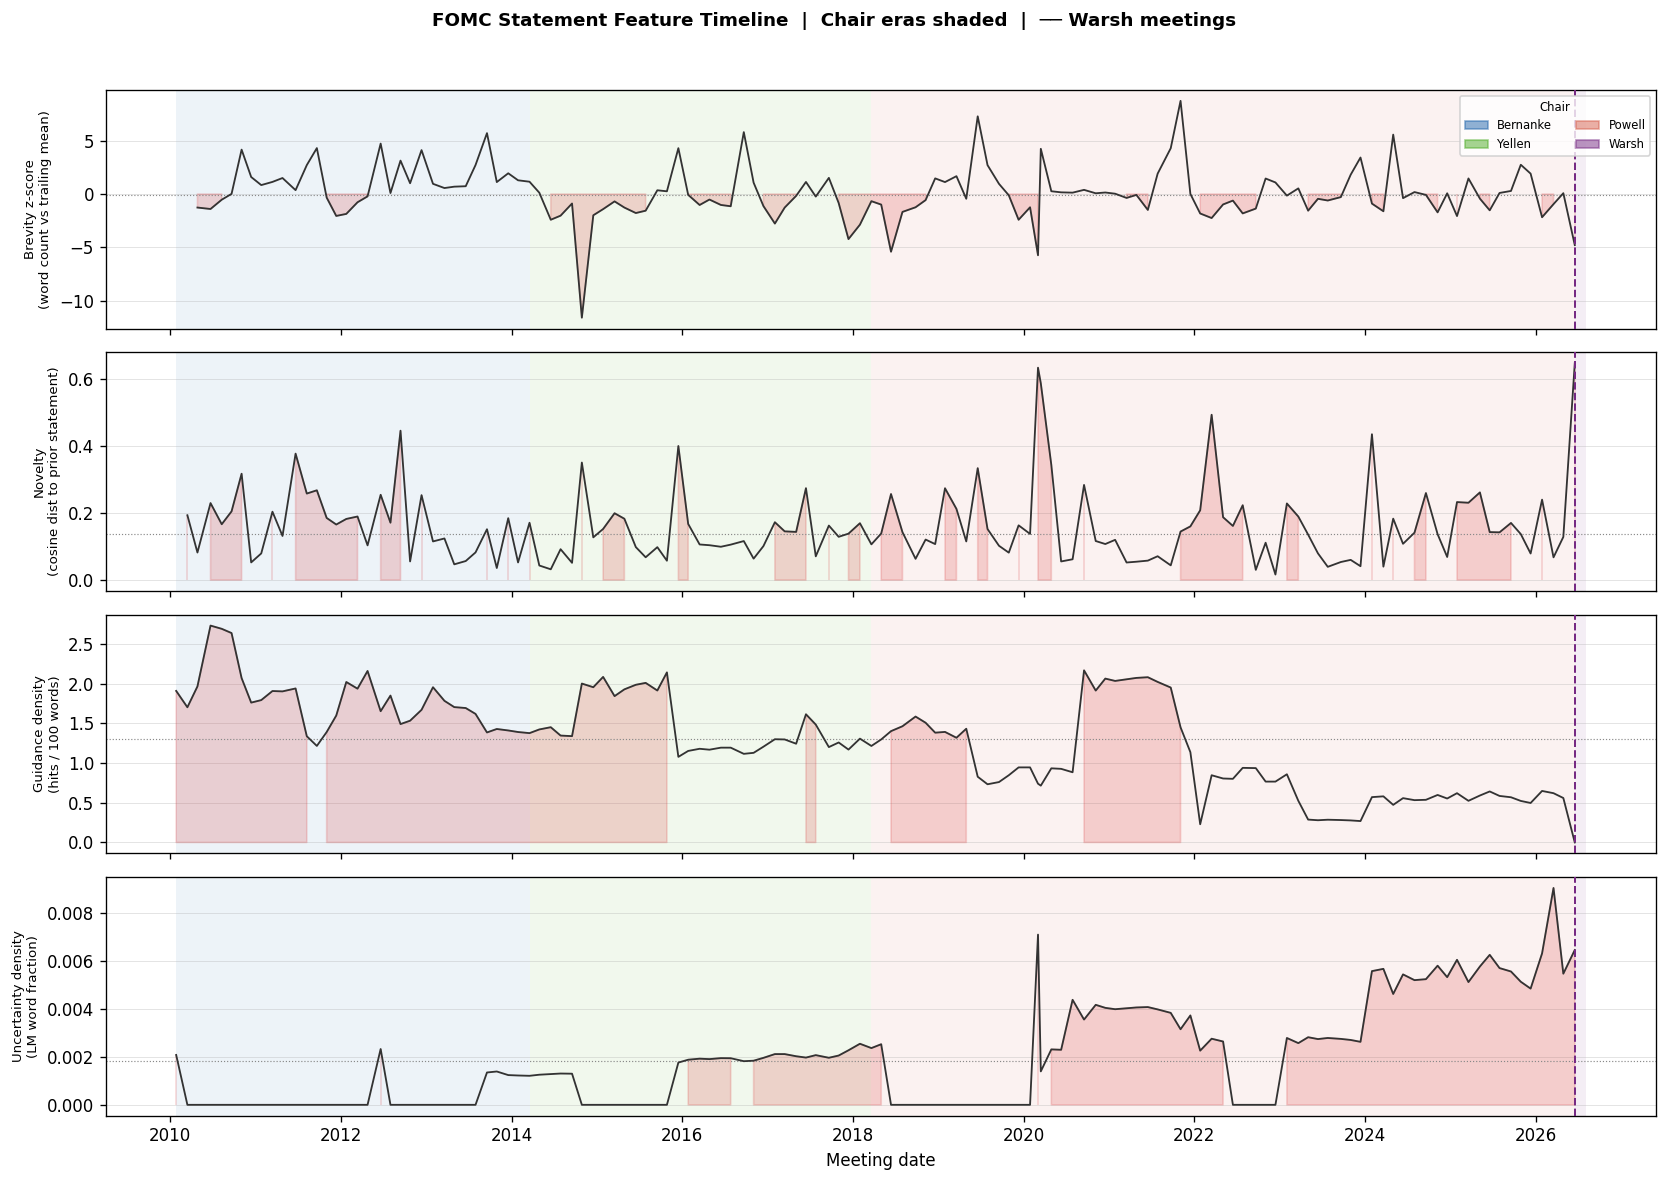

In [30]:

def plot_feature_timeline(df: pd.DataFrame) -> plt.Figure:
    """
    Four-panel time series of the key vol-signal features, with chair era
    shading and vertical markers for Warsh meetings.
    """
    features = [
        ("word_count_zscore",    "Brevity z-score\n(word count vs trailing mean)", True),
        ("novelty_prev",         "Novelty\n(cosine dist to prior statement)",       False),
        ("guidance_density",     "Guidance density\n(hits / 100 words)",            False),
        ("uncertainty_density",  "Uncertainty density\n(LM word fraction)",         False),
    ]

    fig, axes = plt.subplots(len(features), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        "FOMC Statement Feature Timeline  |  Chair eras shaded  |  ── Warsh meetings",
        fontsize=11, fontweight="bold"
    )

    sub = df.dropna(subset=["meeting_date"]).sort_values("meeting_date")

    for ax, (col, ylabel, inverted) in zip(axes, features):
        if col not in sub.columns:
            ax.set_visible(False)
            continue
        _chair_bands(ax, sub)
        vals = sub[col]
        ax.plot(sub["meeting_date"], vals, color="#333333", lw=1.1, zorder=3)
        ax.fill_between(sub["meeting_date"], vals, 0,
                        where=(vals < 0) if inverted else (vals > vals.median()),
                        alpha=0.18, color="#d62728", zorder=2)
        ax.axhline(vals.median(), color="#888888", lw=0.7, ls=":")
        _warsh_vlines(ax, sub)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(axis="y", lw=0.4, alpha=0.5)

    axes[-1].set_xlabel("Meeting date")

    # Chair legend
    patches = [mpatches.Patch(color=c, alpha=0.5, label=ch)
               for ch, c in _CHAIR_COLORS.items() if ch != "Unknown"]
    axes[0].legend(handles=patches, title="Chair", fontsize=7,
                   title_fontsize=7, loc="upper right", ncol=2)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    savefig(fig, "fig1_feature_timeline")
    return fig


fig1 = plot_feature_timeline(master)
plt.show()

  Saved → fomc_viz/fig2_feature_heatmap.png


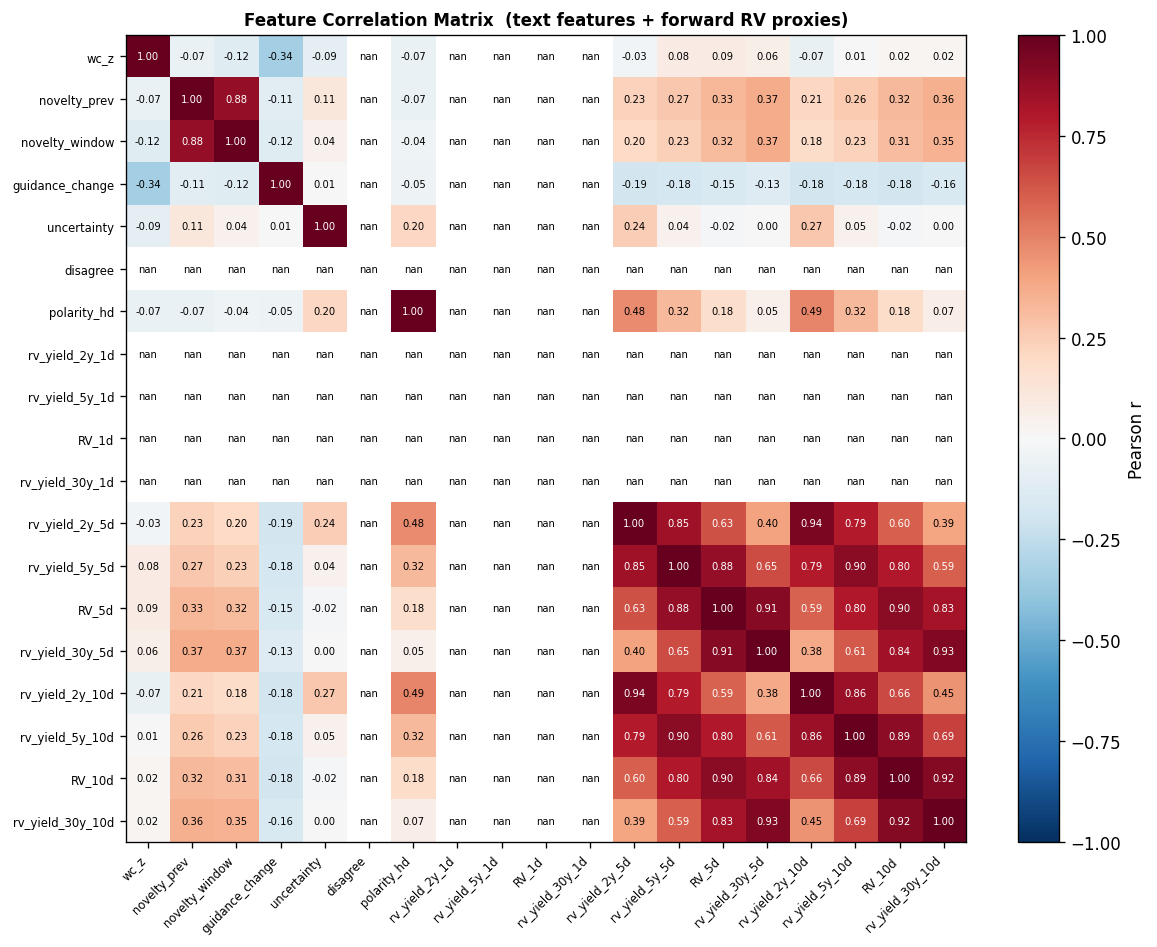

In [31]:

def plot_feature_heatmap(df: pd.DataFrame) -> plt.Figure:
    """
    Pearson correlation matrix of all text features + forward RV.
    Diverging palette so zero = white, positive = red, negative = blue.
    """
    rv_cols   = [c for c in df.columns if c.startswith("rv_yield")]
    all_feats = VOL_FEATURES + ["polarity_hd"] + rv_cols
    sub       = df[[c for c in all_feats if c in df.columns]].dropna(how="all")

    corr = sub.corr()
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr.values, cmap="RdBu_r", norm=norm, aspect="auto")
    plt.colorbar(im, ax=ax, label="Pearson r")

    labels = [c.replace("rv_yield_10y_", "RV_").replace("_density", "")
                .replace("_zscore", "_z").replace("word_count", "wc") for c in corr.columns]
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)

    for i in range(len(corr)):
        for j in range(len(corr)):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if abs(val) > 0.5 else "black")

    ax.set_title("Feature Correlation Matrix  (text features + forward RV proxies)",
                 fontsize=10, fontweight="bold")
    fig.tight_layout()
    savefig(fig, "fig2_feature_heatmap")
    return fig


fig2 = plot_feature_heatmap(master)
plt.show()

  Saved → fomc_viz/fig3_rv_by_chair.png


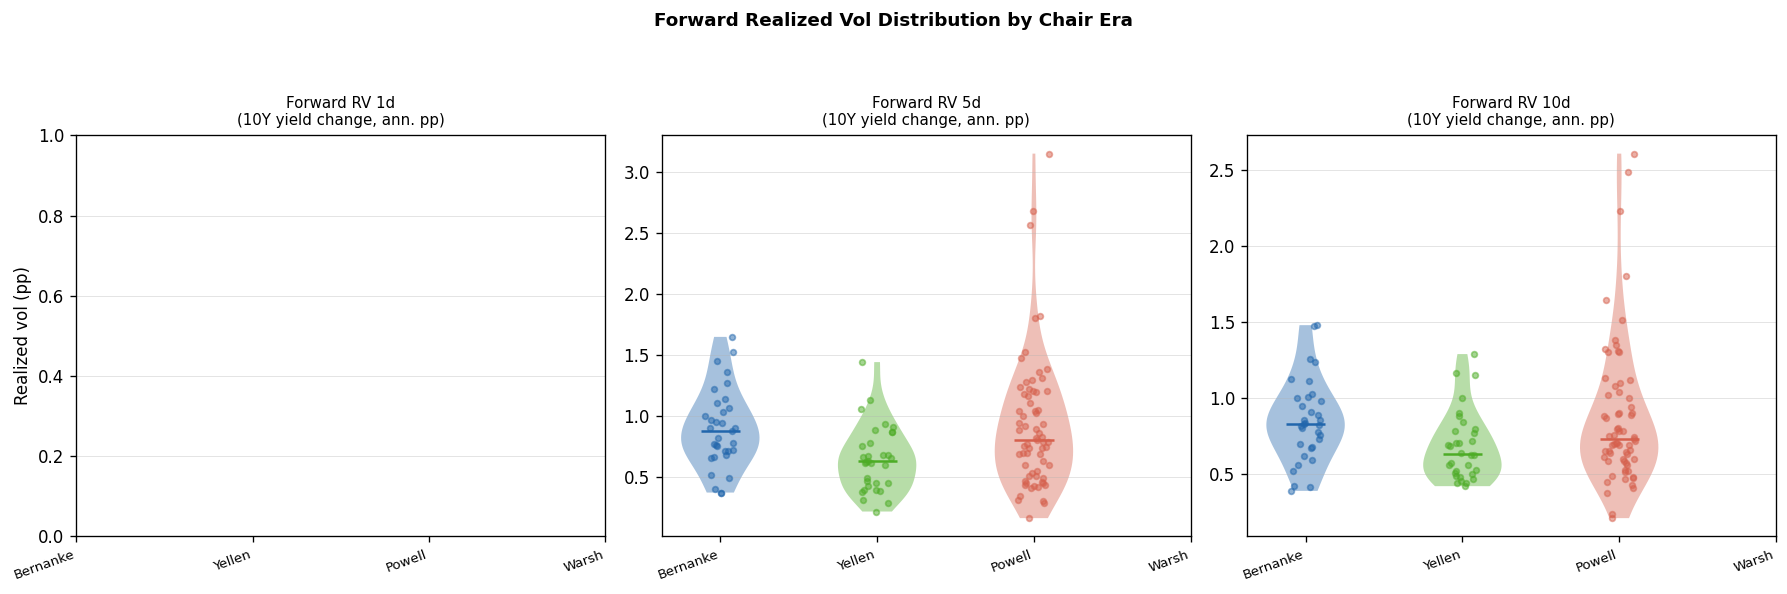

In [32]:

def plot_rv_by_chair(df: pd.DataFrame) -> plt.Figure:
    """
    Violin + strip plot of forward RV at each horizon by chair era.
    Shows whether meeting-day vol regime differs across chairs.
    """
    rv_cols   = [c for c in df.columns if re.match(r"rv_yield_10y_\d+d", c)]
    if not rv_cols:
        print("  No RV columns found — skipping Fig 3.")
        return plt.figure()

    n       = len(rv_cols)
    chairs  = [c for c in _CHAIR_COLORS if c != "Unknown" and c in df["chair"].values]
    x_pos   = np.arange(len(chairs))

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, rv_cols):
        k = col.split("_")[-1]
        for j, chair in enumerate(chairs):
            vals = df[df["chair"] == chair][col].dropna().values
            if len(vals) < 3:
                continue
            parts = ax.violinplot(vals, positions=[j], widths=0.5,
                                  showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(_CHAIR_COLORS[chair])
                pc.set_alpha(0.4)
            parts["cmedians"].set_color(_CHAIR_COLORS[chair])
            ax.scatter(np.full(len(vals), j) + np.random.uniform(-0.1, 0.1, len(vals)),
                       vals, color=_CHAIR_COLORS[chair], alpha=0.5, s=12, zorder=3)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(chairs, rotation=20, ha="right", fontsize=8)
        ax.set_title(f"Forward RV {k}\n(10Y yield change, ann. pp)", fontsize=9)
        ax.set_ylabel("Realized vol (pp)" if ax == axes[0] else "")
        ax.grid(axis="y", lw=0.4, alpha=0.5)

    fig.suptitle("Forward Realized Vol Distribution by Chair Era",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    savefig(fig, "fig3_rv_by_chair")
    return fig


fig3 = plot_rv_by_chair(master)
plt.show()

  Saved → fomc_viz/fig4_classifier_perf.png


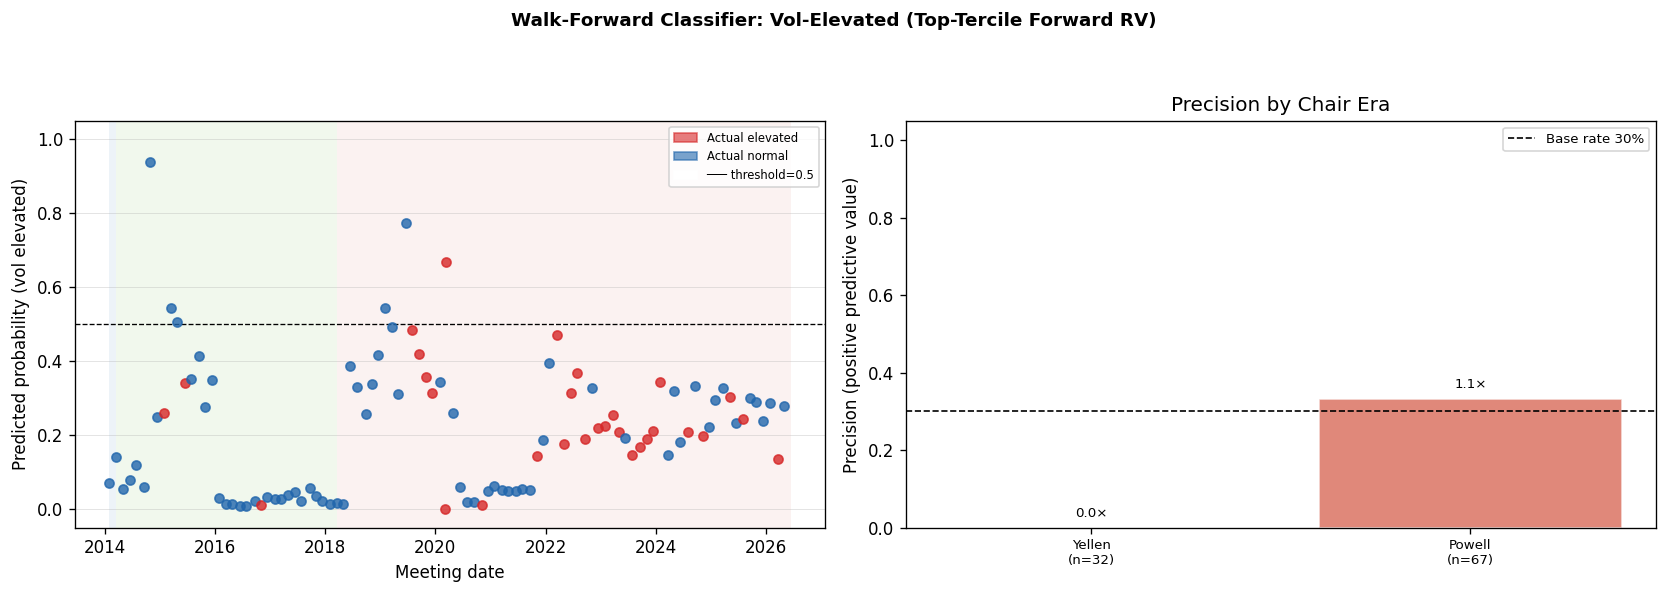

In [33]:

def plot_classifier_perf(clf_df: pd.DataFrame, df: pd.DataFrame) -> plt.Figure:
    """
    Two-panel figure:
      Left:  predicted probability over time, coloured by actual label.
      Right: precision-recall lift bar by chair era.
    """
    if clf_df is None or clf_df.empty:
        print("  No classifier results — skipping Fig 4.")
        return plt.figure()

    clf_df = clf_df.copy()
    clf_df["meeting_date"] = pd.to_datetime(clf_df["meeting_date"])
    clf_merged = clf_df.merge(df[["meeting_date", "chair"]], on="meeting_date", how="left")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Walk-Forward Classifier: Vol-Elevated (Top-Tercile Forward RV)",
                 fontsize=11, fontweight="bold")

    # Left panel — probability time series
    for _, row in clf_merged.iterrows():
        color = "#d62728" if row["actual"] == 1 else "#2166ac"
        ax1.scatter(row["meeting_date"], row["pred_prob"],
                    color=color, s=30, zorder=3, alpha=0.8)

    ax1.axhline(0.5, color="black", lw=0.8, ls="--", label="Decision threshold")
    thresh_line = mpatches.Patch(color="#d62728", alpha=0.6, label="Actual elevated")
    norm_line   = mpatches.Patch(color="#2166ac", alpha=0.6, label="Actual normal")
    ax1.legend(handles=[thresh_line, norm_line,
                         mpatches.Patch(color="white", label="─── threshold=0.5")],
               fontsize=7)
    _chair_bands(ax1,
                 df[df["meeting_date"].isin(clf_merged["meeting_date"])].sort_values("meeting_date"))
    ax1.set_ylabel("Predicted probability (vol elevated)")
    ax1.set_xlabel("Meeting date")
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(axis="y", lw=0.4, alpha=0.5)

    # Right panel — precision by chair era
    base_rate = clf_merged["actual"].mean()
    chair_perf = []
    for chair in [c for c in _CHAIR_COLORS if c != "Unknown"]:
        sub = clf_merged[clf_merged["chair"] == chair]
        if sub.empty or sub["predicted"].sum() == 0:
            continue
        prec = sub[sub["predicted"] == 1]["actual"].mean()
        chair_perf.append({"chair": chair, "precision": prec,
                            "lift": prec / base_rate if base_rate > 0 else np.nan,
                            "n": len(sub)})

    if chair_perf:
        cp_df = pd.DataFrame(chair_perf)
        x     = np.arange(len(cp_df))
        bars  = ax2.bar(x, cp_df["precision"],
                        color=[_CHAIR_COLORS.get(c, "#aaa") for c in cp_df["chair"]],
                        alpha=0.75, edgecolor="white")
        ax2.axhline(base_rate, color="black", lw=1, ls="--",
                    label=f"Base rate {base_rate:.0%}")
        ax2.set_xticks(x)
        ax2.set_xticklabels(
            [f"{r['chair']}\n(n={r['n']})" for _, r in cp_df.iterrows()],
            fontsize=8
        )
        ax2.set_ylabel("Precision (positive predictive value)")
        ax2.set_title("Precision by Chair Era")
        ax2.legend(fontsize=8)
        ax2.set_ylim(0, 1.05)
        # Annotate lift
        for bar, (_, r) in zip(bars, cp_df.iterrows()):
            if not np.isnan(r["lift"]):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.02,
                         f"{r['lift']:.1f}×", ha="center", va="bottom", fontsize=8)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    savefig(fig, "fig4_classifier_perf")
    return fig


_clf_results = clf_results if "clf_results" in dir() else pd.DataFrame()
fig4 = plot_classifier_perf(_clf_results, master)
plt.show()

  Saved → fomc_viz/fig5_bootstrap_ci.png


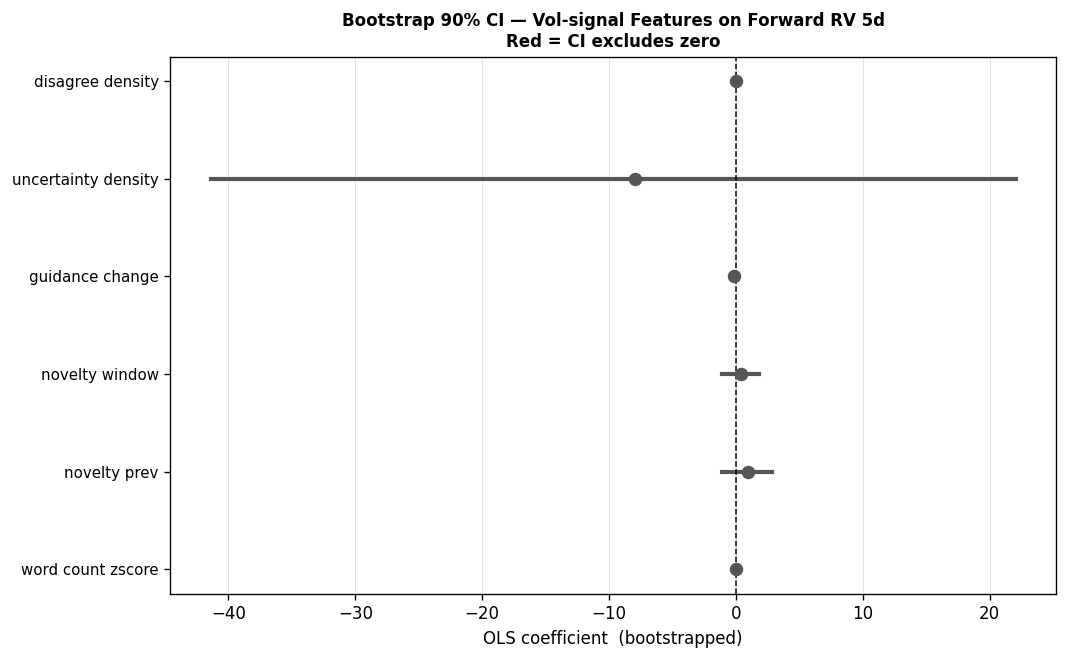

In [34]:

def plot_bootstrap_ci(boot_df: pd.DataFrame) -> plt.Figure:
    """
    Forest plot of bootstrapped OLS coefficients (90 % CI) for the vol-signal
    features.  Features whose CI excludes zero are marked in red.
    """
    if boot_df is None or boot_df.empty:
        print("  No bootstrap results — skipping Fig 5.")
        return plt.figure()

    ci_cols = [c for c in boot_df.columns if c.startswith("ci_")]
    if len(ci_cols) < 2:
        return plt.figure()
    lo_col, hi_col = ci_cols[0], ci_cols[1]
    ci_pct = ci_cols[0].split("_")[1]

    fig, ax = plt.subplots(figsize=(9, 0.6 * len(boot_df) + 2))
    y_pos = np.arange(len(boot_df))

    for i, (_, row) in enumerate(boot_df.iterrows()):
        color = "#d62728" if row["sig"] else "#555555"
        ax.plot([row[lo_col], row[hi_col]], [i, i], color=color, lw=2.5)
        ax.scatter(row["coef_mean"], i, color=color, s=50, zorder=4)

    ax.axvline(0, color="black", lw=0.9, ls="--")
    labels = [r["feature"].replace("_", " ") for _, r in boot_df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("OLS coefficient  (bootstrapped)")
    ax.set_title(f"Bootstrap {ci_pct}% CI — Vol-signal Features on Forward RV 5d\n"
                 "Red = CI excludes zero", fontsize=10, fontweight="bold")
    ax.grid(axis="x", lw=0.4, alpha=0.5)
    fig.tight_layout()
    savefig(fig, "fig5_bootstrap_ci")
    return fig


_boot_df = boot_df if "boot_df" in dir() else pd.DataFrame()
fig5 = plot_bootstrap_ci(_boot_df)
plt.show()

  Saved → fomc_viz/fig6_warsh_spotlight.png


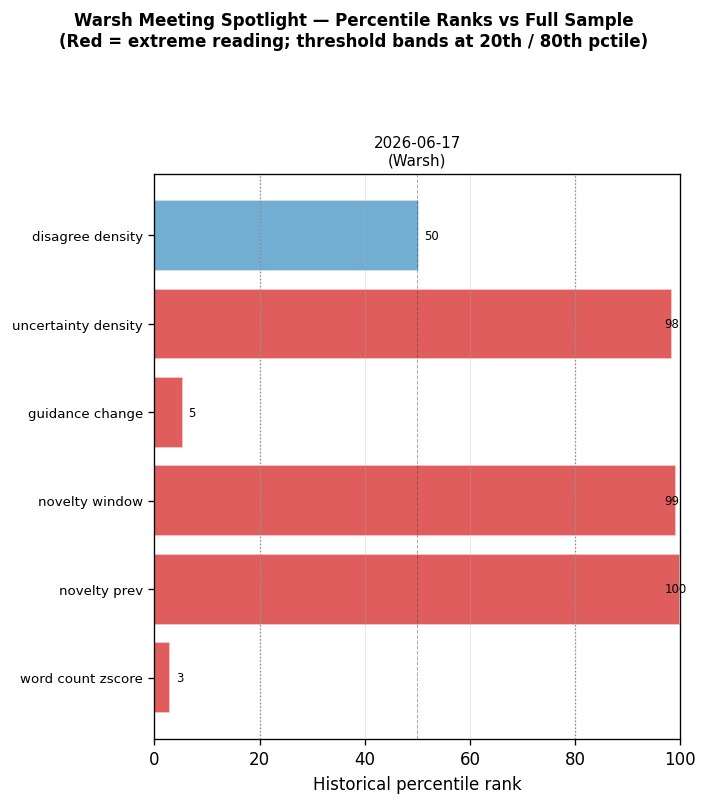

In [35]:

def plot_warsh_spotlight(df: pd.DataFrame, feature_cols: list[str]) -> plt.Figure:
    """
    Radar / percentile bar chart showing each Warsh meeting's feature vector
    relative to the full-sample distribution.  Each bar spans 0-100 pctile;
    a red fill above 80 or below 20 flags an extreme reading.
    """
    warsh = df[df["chair"] == "Warsh"].dropna(subset=feature_cols, how="all")
    if warsh.empty:
        print("  No Warsh meetings in master — skipping Fig 6.")
        return plt.figure()

    n_meetings = len(warsh)
    n_feats    = len(feature_cols)

    fig, axes = plt.subplots(1, n_meetings,
                             figsize=(6 * n_meetings, 5 + n_feats * 0.3),
                             squeeze=False)
    fig.suptitle("Warsh Meeting Spotlight — Percentile Ranks vs Full Sample\n"
                 "(Red = extreme reading; threshold bands at 20th / 80th pctile)",
                 fontsize=10, fontweight="bold")

    for ax, (_, row) in zip(axes[0], warsh.iterrows()):
        pctiles = []
        for feat in feature_cols:
            val = row.get(feat, np.nan)
            if pd.isna(val):
                pctiles.append(np.nan)
            else:
                pctiles.append(
                    sp_stats.percentileofscore(df[feat].dropna().values, val, kind="rank")
                )

        y      = np.arange(n_feats)
        colors = ["#d62728" if (p <= 20 or p >= 80) else "#4393c3"
                  for p in pctiles]
        bars   = ax.barh(y, pctiles, color=colors, alpha=0.75, edgecolor="white")

        ax.axvline(20, color="#888888", lw=0.8, ls=":")
        ax.axvline(80, color="#888888", lw=0.8, ls=":")
        ax.axvline(50, color="#333333", lw=0.6, ls="--", alpha=0.4)

        ax.set_xlim(0, 100)
        ax.set_yticks(y)
        ax.set_yticklabels([f.replace("_", " ") for f in feature_cols], fontsize=8)
        ax.set_xlabel("Historical percentile rank")
        ax.set_title(f"{row['meeting_date'].date()}\n(Warsh)", fontsize=9)
        ax.grid(axis="x", lw=0.4, alpha=0.4)

        # Annotate percentile values
        for bar, p in zip(bars, pctiles):
            if not np.isnan(p):
                ax.text(min(p + 1, 97), bar.get_y() + bar.get_height() / 2,
                        f"{p:.0f}",
                        va="center", ha="left", fontsize=7)

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    savefig(fig, "fig6_warsh_spotlight")
    return fig


fig6 = plot_warsh_spotlight(master, VOL_FEATURES)
plt.show()

---
## Fig 7 — Fed Chair Word Clouds
Word size = frequency across all statements for that chair.
Colour encodes semantic category:
🔴 Uncertainty / volatility · 🟢 Stability / confidence · 🟣 Rate hike / tightening · 🔵 Rate cut / easing · ⚫ Neutral

  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20110921.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20110921.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20111213.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20111213.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20130130.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20130130.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140129.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140129.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140430.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20140430.htm


...

  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160127.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160127.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160427.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20160427.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20180131.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20180131.htm


  FETCH FAILED  https://www.federalreserve.gov/monetarypolicy/fomcpresconf20260128.htm
  404 Client Error: Not Found for url: https://www.federalreserve.gov/monetarypolicy/fomcpresconf20260128.htm

docs_raw: (216, 7)
doc_type
presser       83
statement    133


  Saved → fomc_viz/fig7_chair_wordclouds.png


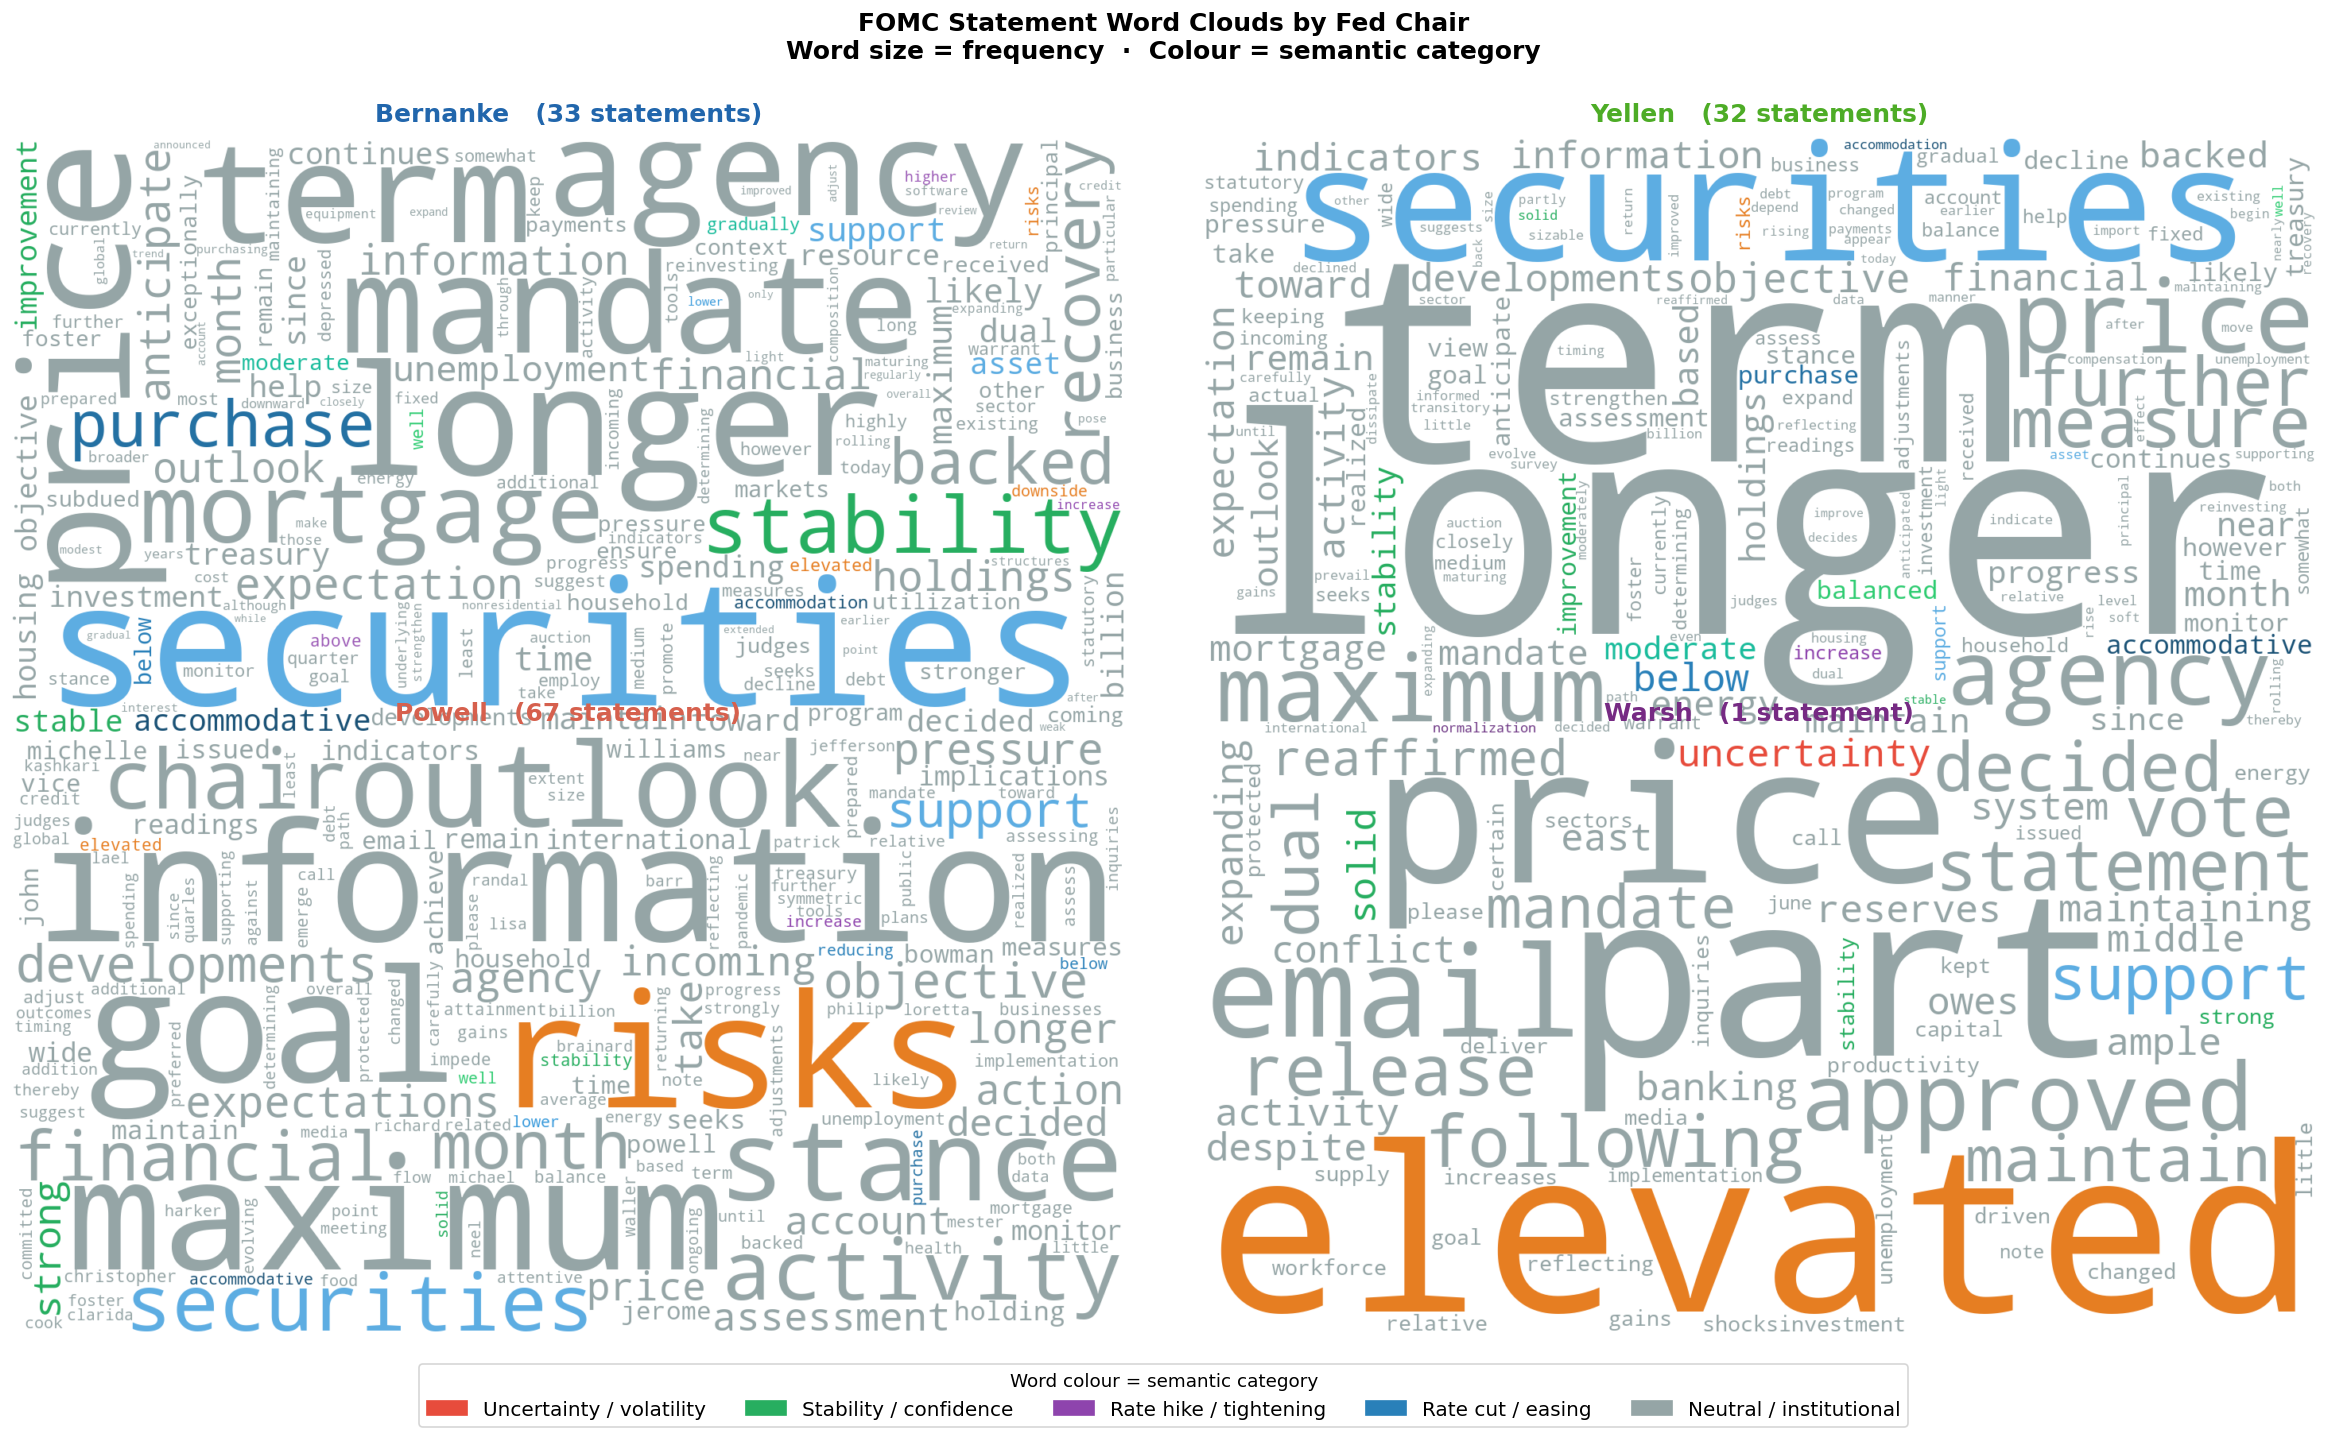


══════════════════════════════════════════════════════════════
  All figures saved to: /Users/zinuoshi/fomc_viz
  fomc_features.parquet: /Users/zinuoshi/fomc_features.parquet
══════════════════════════════════════════════════════════════


In [36]:

from wordcloud import WordCloud

# Semantic colour map — add or adjust terms here
_WORD_COLORS: dict[str, str] = {
    # Uncertainty / volatility → red-orange
    "uncertain":       "#e74c3c", "uncertainty":    "#e74c3c",
    "volatile":        "#c0392b", "volatility":     "#c0392b",
    "risk":            "#e67e22", "risks":          "#e67e22",
    "turbulent":       "#c0392b", "challenging":    "#e74c3c",
    "adverse":         "#c0392b", "downside":       "#e67e22",
    "concern":         "#e74c3c", "concerns":       "#e74c3c",
    "elevated":        "#e67e22", "heightened":     "#e74c3c",
    "disruptions":     "#c0392b", "stressed":       "#c0392b",
    "headwinds":       "#e67e22", "deteriorated":   "#c0392b",
    "tensions":        "#e74c3c", "trade":          "#e67e22",
    # Stability / confidence → green-teal
    "stable":          "#27ae60", "stability":      "#27ae60",
    "balanced":        "#2ecc71", "sustainable":    "#27ae60",
    "anchored":        "#1abc9c", "resilient":      "#16a085",
    "solid":           "#27ae60", "steady":         "#2ecc71",
    "robust":          "#27ae60", "consistent":     "#1abc9c",
    "confident":       "#27ae60", "confidence":     "#27ae60",
    "strength":        "#2ecc71", "strong":         "#27ae60",
    "moderate":        "#1abc9c", "gradually":      "#1abc9c",
    "well":            "#2ecc71", "improvement":    "#27ae60",
    # Rate hike / tightening → purple
    "increase":        "#8e44ad", "increasing":     "#8e44ad",
    "raised":          "#8e44ad", "raising":        "#7d3c98",
    "restrictive":     "#6c3483", "tighten":        "#8e44ad",
    "tightening":      "#6c3483", "higher":         "#9b59b6",
    "normalize":       "#8e44ad", "normalization":  "#6c3483",
    "remove":          "#7d3c98", "hike":           "#6c3483",
    "overshoot":       "#8e44ad", "above":          "#9b59b6",
    # Rate cut / easing → blue
    "decrease":        "#2980b9", "lower":          "#3498db",
    "lowering":        "#2980b9", "accommodative":  "#1a5276",
    "easing":          "#2471a3", "ease":           "#3498db",
    "reduce":          "#2980b9", "reducing":       "#2980b9",
    "cut":             "#2471a3", "support":        "#5dade2",
    "stimulus":        "#1a5276", "accommodation":  "#1a5276",
    "below":           "#2980b9", "purchase":       "#2471a3",
    "purchases":       "#2471a3", "asset":          "#5dade2",
    "securities":      "#5dade2", "quantitative":   "#1a5276",
}

_NEUTRAL_COLOR = "#95a5a6"

_WC_STOP = {
    "the", "and", "for", "that", "has", "with", "will", "from", "this",
    "have", "are", "its", "been", "was", "were", "which", "not", "but",
    "more", "also", "than", "their", "they", "these", "would", "could",
    "should", "may", "can", "all", "such", "over", "under", "into",
    "about", "out", "when", "some", "our", "committee", "federal",
    "open", "market", "voting", "voted", "reserve", "bank", "board",
    "members", "rates", "rate", "percent", "basis", "points", "funds",
    "range", "target", "monetary", "policy", "economic", "economy",
    "conditions", "inflation", "employment", "labor", "growth", "year",
    "period", "recent", "continue", "continued", "remains", "remained",
    "expects", "expected", "consistent", "including", "determine",
    "appropriate", "assessed", "current", "levels", "pace", "future",
}


def _wc_color(word, **kwargs):
    return _WORD_COLORS.get(word.lower(), _NEUTRAL_COLOR)


def plot_chair_wordclouds(docs_df: pd.DataFrame,
                          calendar_df: pd.DataFrame) -> plt.Figure:
    """
    4-panel word cloud — one per Fed chair.
    Word size ∝ term frequency across all that chair's statements.
    Colour encodes semantic category via _wc_color.
    """
    stmt = docs_df[docs_df["doc_type"] == "statement"].copy()
    # chair is already on docs_df; if not, join from calendar
    if "chair" not in stmt.columns:
        _cal = calendar_df[["meeting_date", "chair"]].copy()
        _cal["meeting_date"] = pd.to_datetime(_cal["meeting_date"])
        stmt["meeting_date"] = pd.to_datetime(stmt["meeting_date"])
        stmt = stmt.merge(_cal, on="meeting_date", how="left")

    chairs = ["Bernanke", "Yellen", "Powell", "Warsh"]
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes_flat = axes.flatten()

    for ax, chair in zip(axes_flat, chairs):
        sub = stmt[stmt["chair"] == chair]
        if sub.empty:
            ax.set_title(f"{chair} — no statements", fontsize=13)
            ax.axis("off")
            continue

        corpus = " ".join(sub["text"].fillna("").tolist())
        corpus = re.sub(r"[^a-zA-Z\s]", " ", corpus.lower())
        corpus = re.sub(r"\b\w{1,3}\b", " ", corpus)   # drop very short words
        corpus = re.sub(r"\s+", " ", corpus).strip()

        wc = WordCloud(
            width=1400, height=750,
            background_color="white",
            max_words=160,
            color_func=_wc_color,
            stopwords=_WC_STOP,
            prefer_horizontal=0.85,
            random_state=42,
            collocations=False,
            min_font_size=10,
        ).generate(corpus)

        ax.imshow(wc, interpolation="bilinear")
        n = len(sub)
        ax.set_title(
            f"{chair}   ({n} statement{'s' if n != 1 else ''})",
            fontsize=15, fontweight="bold",
            color=_CHAIR_COLORS.get(chair, "#333333"),
            pad=10,
        )
        ax.axis("off")

    # Colour legend
    legend_handles = [
        mpatches.Patch(color="#e74c3c", label="Uncertainty / volatility"),
        mpatches.Patch(color="#27ae60", label="Stability / confidence"),
        mpatches.Patch(color="#8e44ad", label="Rate hike / tightening"),
        mpatches.Patch(color="#2980b9", label="Rate cut / easing"),
        mpatches.Patch(color="#95a5a6", label="Neutral / institutional"),
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=5,
        fontsize=12, frameon=True, bbox_to_anchor=(0.5, -0.01),
        title="Word colour = semantic category", title_fontsize=11,
    )
    fig.suptitle(
        "FOMC Statement Word Clouds by Fed Chair\n"
        "Word size = frequency  ·  Colour = semantic category",
        fontsize=15, fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    savefig(fig, "fig7_chair_wordclouds")
    return fig


# Re-build docs from cache (all HTML already on disk — no network calls)
_docs_wc = build_docs_raw(calendar_df)
fig7 = plot_chair_wordclouds(_docs_wc, calendar_df)
plt.show()

print(f"\n{'═'*62}")
print(f"  All figures saved to: {VIZ_OUT.resolve()}")
print(f"  fomc_features.parquet: {PARQUET_OUT.resolve()}")
print("═" * 62)